# Article Distribution Figures (1-9)

This notebook generates all figures described in `plots/image_generation_prompts.md`.

- Default mode: publication-safe style (white background, grayscale-safe, 300 DPI)
- Optional mode: fancy style via `FANCY_STYLE = True`
- Outputs: PNG files saved in `plots/generated_figures/`

In [2]:
import re
import xml.etree.ElementTree as ET
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
from matplotlib import colors as mcolors

In [3]:
# -------------------------
# Global config
# -------------------------
FANCY_STYLE = False
SAVE_FIGURES = True
SHOW_FIGURES = True

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PALETTE = {
    "blue": "#4477AA",
    "red": "#EE6677",
    "teal": "#228833",
    "amber": "#CCBB44",
    "purple": "#AA3377",
    "gray": "#BBBBBB",
    "dark_gray": "#666666",
}

SOURCE_COUNTS = {"arXiv": 1108, "PMC": 570, "Other": 254}

ARXIV_TOP10 = {
    "eess.IV": 382,
    "cs.CV": 263,
    "cs.LG": 72,
    "q-bio.QM": 32,
    "cs.CL": 23,
    "cs.AI": 18,
    "q-bio.GN": 17,
    "physics.med-ph": 14,
    "q-bio.PE": 11,
    "cs.CR": 8,
}

YEAR_COUNTS = {
    2000: 6, 2001: 6, 2002: 7, 2003: 4, 2004: 3, 2005: 7, 2006: 8, 2007: 10, 2008: 4,
    2009: 9, 2010: 9, 2011: 12, 2012: 15, 2013: 9, 2014: 51, 2015: 60, 2016: 33, 2017: 40,
    2018: 47, 2019: 41, 2020: 276, 2021: 386, 2022: 96, 2023: 58, 2024: 40, 2025: 109, 2026: 566
}

VENUE_TOP15 = {
    "Lect. Notes Comput. Sci.": 56,
    "IEEE Trans. Med. Imaging": 44,
    "Diagnostics": 36,
    "Med. Image Anal.": 34,
    "Front. Public Health": 29,
    "Sci. Rep.": 23,
    "J. Clin. Med.": 23,
    "Nature": 22,
    "CA Cancer J. Clin.": 22,
    "Sci. Data": 21,
    "PLOS ONE": 19,
    "Radiology": 17,
    "NeuroImage": 16,
    "Sensors": 16,
    "Front. Med.": 15,
}

ARTICLE_TYPES = {
    "Preprint": 1108,
    "Research Article": 406,
    "Journal Article": 254,
    "Review Article": 111,
    "Other": 53,
}

KEYWORD_TOP20 = {
    "deep learning": 249,
    "machine learning": 107,
    "segmentation": 85,
    "artificial intelligence": 62,
    "MRI": 58,
    "COVID-19": 51,
    "brain tumor segmentation": 50,
    "medical imaging": 49,
    "transfer learning": 47,
    "convolutional neural network": 40,
    "classification": 30,
    "image segmentation": 29,
    "CNN": 26,
    "U-Net": 25,
    "magnetic resonance imaging": 22,
    "medical image analysis": 20,
    "glioma": 19,
    "data augmentation": 19,
    "semi-supervised learning": 19,
    "contrastive learning": 19,
}

TREEMAP_DOMAINS = [
    ("Medical Imaging & Segmentation", 516, PALETTE["blue"]),
    ("Machine Learning Methods", 224, PALETTE["red"]),
    ("Clinical Applications", 142, PALETTE["teal"]),
    ("Advanced AI Techniques", 81, PALETTE["amber"]),
    ("Bioinformatics & Genomics", 36, PALETTE["purple"]),
]

def blend_with_white(color, blend=0.25):
    rgb = np.array(mcolors.to_rgb(color))
    white = np.array([1.0, 1.0, 1.0])
    out = rgb * (1 - blend) + white * blend
    return mcolors.to_hex(out)

def blend_with_black(color, blend=0.20):
    rgb = np.array(mcolors.to_rgb(color))
    black = np.array([0.0, 0.0, 0.0])
    out = rgb * (1 - blend) + black * blend
    return mcolors.to_hex(out)

def apply_style(fancy=False):
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": ["Arial", "DejaVu Sans", "sans-serif"],
        "font.size": 10,
        "axes.edgecolor": "black",
        "axes.linewidth": 0.9,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "savefig.dpi": 300,
    })

    if fancy:
        plt.rcParams.update({
            "axes.facecolor": "#FAFBFD",
            "grid.color": "#CFD6DE",
            "grid.linestyle": "-.",
            "grid.linewidth": 0.7,
        })

def style_axes(ax, xlabel=None, ylabel=None, x_grid=False, y_grid=True):
    for side in ["top", "right", "bottom", "left"]:
        ax.spines[side].set_color("black")
        ax.spines[side].set_linewidth(0.9)

    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

    if x_grid:
        ax.grid(axis="x", linestyle="--", color="#D9D9D9", linewidth=0.7)
    if y_grid:
        ax.grid(axis="y", linestyle="--", color="#D9D9D9", linewidth=0.7)
    ax.set_axisbelow(True)

def add_caption(fig, text):
    fig.text(0.5, 0.01, text, ha="center", va="bottom", fontsize=9, style="italic", wrap=True)

def finalize_figure(fig, file_name):
    fig.tight_layout(rect=[0, 0.08, 1, 1])
    if SAVE_FIGURES:
        fig.savefig(OUTPUT_DIR / file_name, dpi=300, bbox_inches="tight")
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)

# -------------------------
# Figure 7 helper data
# -------------------------
TEI_NS = {"tei": "http://www.tei-c.org/ns/1.0"}

def _get_tei_year(root, stem):
    date_el = root.find('.//tei:publicationStmt/tei:date[@type="published"]', TEI_NS)
    if date_el is not None:
        when = date_el.get("when", "")
        m = re.match(r"(\d{4})", when)
        if m:
            return int(m.group(1))

    monogr_date = root.find('.//tei:monogr//tei:date[@type="published"]', TEI_NS)
    if monogr_date is not None:
        when = monogr_date.get("when", "")
        m = re.match(r"(\d{4})", when)
        if m:
            return int(m.group(1))

    m = re.match(r"(\d{2})(\d{2})\.", stem)
    if m:
        yy = int(m.group(1))
        return 2000 + yy if yy < 50 else 1900 + yy

    return None

def _get_pmc_year(root):
    for pub_type in ["epub", "ppub", None]:
        if pub_type:
            year_el = root.find(f'.//pub-date[@pub-type="{pub_type}"]/year')
        else:
            year_el = root.find('.//pub-date/year')

        if year_el is not None and year_el.text and year_el.text.strip().isdigit():
            return int(year_el.text.strip())

    return None

def load_year_source_counts(years):
    counts = {y: {"arXiv": 0, "PMC": 0, "Other": 0} for y in years}

    tei_dir = Path("tei_output")
    if tei_dir.exists():
        for p in tei_dir.glob("*.tei.xml"):
            try:
                root = ET.parse(p).getroot()
                year = _get_tei_year(root, p.stem)
                if year not in counts:
                    continue

                arxiv_el = root.find('.//tei:idno[@type="arXiv"]', TEI_NS)
                src = "arXiv" if (arxiv_el is not None and (arxiv_el.text or "").strip()) else "Other"
                counts[year][src] += 1
            except Exception:
                pass

    pmc_dir = Path("xml")
    if pmc_dir.exists():
        for p in pmc_dir.glob("*.xml"):
            try:
                root = ET.parse(p).getroot()
                year = _get_pmc_year(root)
                if year in counts:
                    counts[year]["PMC"] += 1
            except Exception:
                pass

    return counts

def _proportional_int_split(total, weights):
    if total <= 0:
        return [0 for _ in weights]
    w = np.array(weights, dtype=float)
    if w.sum() == 0:
        w = np.ones_like(w)
    raw = total * (w / w.sum())
    ints = np.floor(raw).astype(int)
    remain = total - ints.sum()
    frac_order = np.argsort(raw - ints)[::-1]
    for i in frac_order[:remain]:
        ints[i] += 1
    return ints.tolist()

def reconcile_year_source_counts(raw_counts, target_totals):
    out = {}
    for year, target in target_totals.items():
        row = raw_counts.get(year, {"arXiv": 0, "PMC": 0, "Other": 0})
        current = row["arXiv"] + row["PMC"] + row["Other"]

        if current == target:
            out[year] = row
            continue

        if current == 0:
            if year in (2020, 2021):
                weights = [0.75, 0.15, 0.10]
            elif year == 2026:
                weights = [0.30, 0.55, 0.15]
            else:
                weights = [0.573, 0.295, 0.131]
        else:
            weights = [row["arXiv"], row["PMC"], row["Other"]]

        arxiv_i, pmc_i, other_i = _proportional_int_split(target, weights)
        out[year] = {"arXiv": arxiv_i, "PMC": pmc_i, "Other": other_i}

    return out

def get_year_source_data_2014_2026():
    years = list(range(2014, 2027))
    raw = load_year_source_counts(years)
    targets = {y: YEAR_COUNTS[y] for y in years}
    reconciled = reconcile_year_source_counts(raw, targets)
    return years, reconciled

In [4]:
def plot_figure1_source_distribution(fancy=False):
    apply_style(fancy)
    labels = ["arXiv", "PubMed Central", "Other sources"]
    values = [1108, 570, 254]
    colors = [PALETTE["blue"], PALETTE["red"], PALETTE["teal"]]

    fig, ax = plt.subplots(figsize=(8.2, 6.3), dpi=300)
    wedges, _ = ax.pie(
        values,
        startangle=90,
        counterclock=False,
        colors=colors,
        wedgeprops=dict(width=0.40, edgecolor="white", linewidth=2.0),
    )

    total = sum(values)
    for wedge, label, value in zip(wedges, labels, values):
        ang = (wedge.theta1 + wedge.theta2) / 2
        ang_rad = np.deg2rad(ang)
        x, y = np.cos(ang_rad), np.sin(ang_rad)
        ax.annotate(
            f"{label}: {value} ({value/total*100:.1f}%)",
            xy=(0.82 * x, 0.82 * y),
            xytext=(1.25 * np.sign(x), 1.15 * y),
            ha="left" if x >= 0 else "right",
            va="center",
            fontsize=9,
            arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
        )

    ax.text(0, 0, "N = 1,932", ha="center", va="center", fontsize=14, fontweight="bold")

    legend_handles = [Patch(facecolor=c, edgecolor="black", label=l) for c, l in zip(colors, labels)]
    ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=9)
    ax.set_title("Distribution of Collected Articles by Source", fontsize=13, fontweight="bold", pad=15)
    ax.set_aspect("equal")
    ax.axis("off")

    # caption = (
    #     "Fig. 1. Distribution of collected articles by source repository (N = 1,932). "
    #     "arXiv preprints constitute the majority (57.3%), followed by PubMed Central "
    #     "(29.5%) and other indexed sources (13.1%)."
    # )
    # add_caption(fig, caption)
    finalize_figure(fig, "fig1_source_distribution.png")


def plot_figure2_arxiv_breakdown(fancy=False):
    apply_style(fancy)
    labels = list(ARXIV_TOP10.keys())
    values = list(ARXIV_TOP10.values())

    fig, ax = plt.subplots(figsize=(9.5, 6.8), dpi=300)
    y = np.arange(len(labels))
    ax.barh(y, values, color=PALETTE["blue"], edgecolor="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontfamily="monospace")
    ax.invert_yaxis()
    ax.set_xlim(0, 410)
    ax.set_xticks(np.arange(0, 401, 50))

    for yi, v in zip(y, values):
        ax.text(v + 4, yi, str(v), va="center", ha="left", fontsize=9)

    style_axes(ax, xlabel="Number of articles", y_grid=True)
    ax.set_title("ArXiv Preprints by Category", fontsize=13, fontweight="bold", pad=12)

    caption = (
        "Fig. 2. Distribution of arXiv preprints by primary category (n = 909). "
        "Image and signal processing (eess.IV) and computer vision (cs.CV) together "
        "account for 70.9% of categorized submissions."
    )
    add_caption(fig, caption)
    finalize_figure(fig, "fig2_arxiv_category_breakdown.png")


def plot_figure3_year_distribution(fancy=False):
    apply_style(fancy)
    years = sorted(YEAR_COUNTS.keys())
    counts = [YEAR_COUNTS[y] for y in years]

    fig, ax = plt.subplots(figsize=(12.5, 6.5), dpi=300)
    bars = ax.bar(years, counts, color=PALETTE["blue"], edgecolor="black", linewidth=0.8)

    for b, val in zip(bars, counts):
        x = b.get_x() + b.get_width() / 2
        y = b.get_height()
        if val < 20:
            ax.text(x, y + 3, str(val), ha="center", va="bottom", fontsize=8, rotation=90)
        else:
            ax.text(x, y + 4, str(val), ha="center", va="bottom", fontsize=8)

    ax.set_ylim(0, 610)
    ax.set_yticks(np.arange(0, 601, 100))
    ax.set_xticks(years)
    ax.set_xticklabels(years, rotation=45, ha="right")

    style_axes(ax, xlabel="Publication year", ylabel="Number of articles", y_grid=True)
    ax.set_title("Temporal Distribution of Articles by Publication Year", fontsize=13, fontweight="bold", pad=12)

    # caption = (
    #     "Fig. 3. Temporal distribution of articles by publication year (N = 1,932, "
    #     "years before 2000 excluded for clarity, n = 24). A marked increase is observed "
    #     "from 2019 onward, with peaks in 2020-2021 coinciding with the COVID-19 pandemic "
    #     "and in 2026 reflecting recent PubMed Central acquisitions."
    # )
    # add_caption(fig, caption)
    finalize_figure(fig, "fig3_publication_year_distribution.png")


def plot_figure4_top_venues(fancy=False):
    apply_style(fancy)
    labels = list(VENUE_TOP15.keys())
    values = list(VENUE_TOP15.values())

    y = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(10.5, 7.2), dpi=300)
    ax.barh(y, values, color=PALETTE["dark_gray"], edgecolor="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlim(0, 62)
    ax.set_xticks(np.arange(0, 61, 10))

    for yi, v in zip(y, values):
        ax.text(v + 0.8, yi, str(v), va="center", ha="left", fontsize=9)

    style_axes(ax, xlabel="Number of articles", y_grid=True)
    ax.set_title("Top 15 Publication Venues by Article Count", fontsize=13, fontweight="bold", pad=12)

    caption = (
        "Fig. 4. Top 15 publication venues ranked by article count (out of 987 unique venues). "
        "Lecture Notes in Computer Science and IEEE Transactions on Medical Imaging are the "
        "most represented, reflecting the interdisciplinary nature of medical AI research."
    )
    add_caption(fig, caption)
    finalize_figure(fig, "fig4_top15_journals_venues.png")

Generating figures with fancy_style=False ...


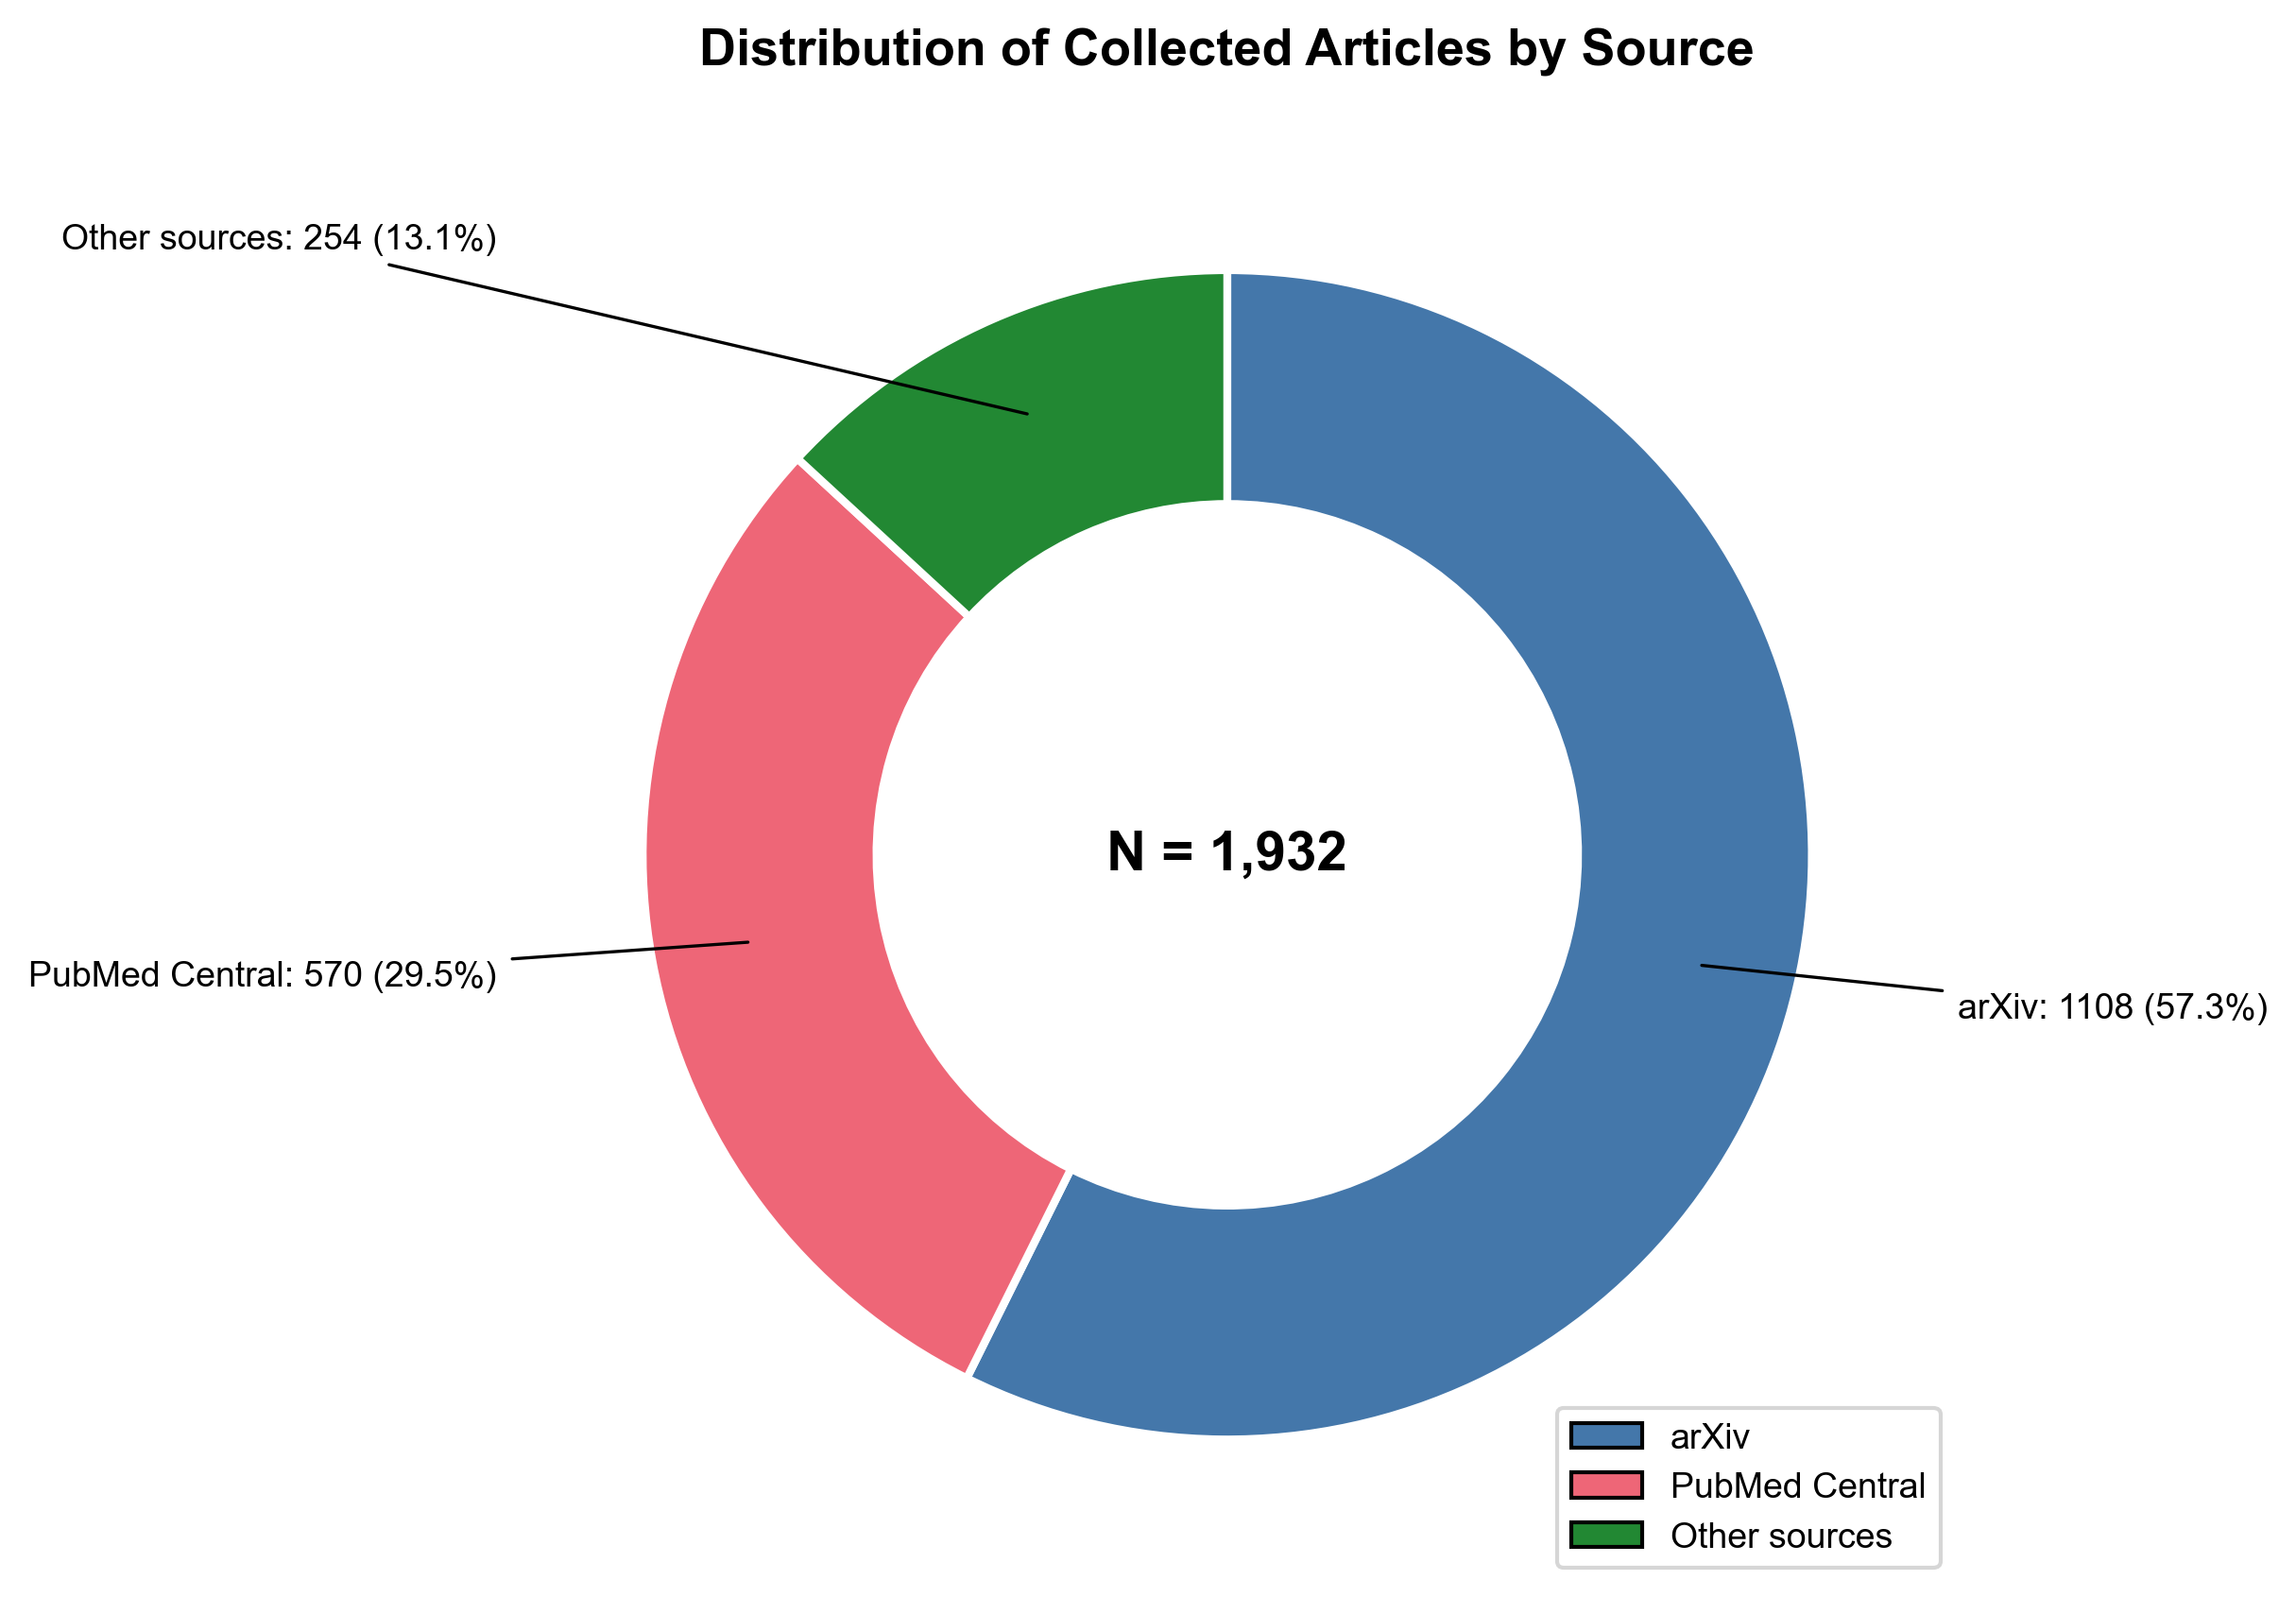

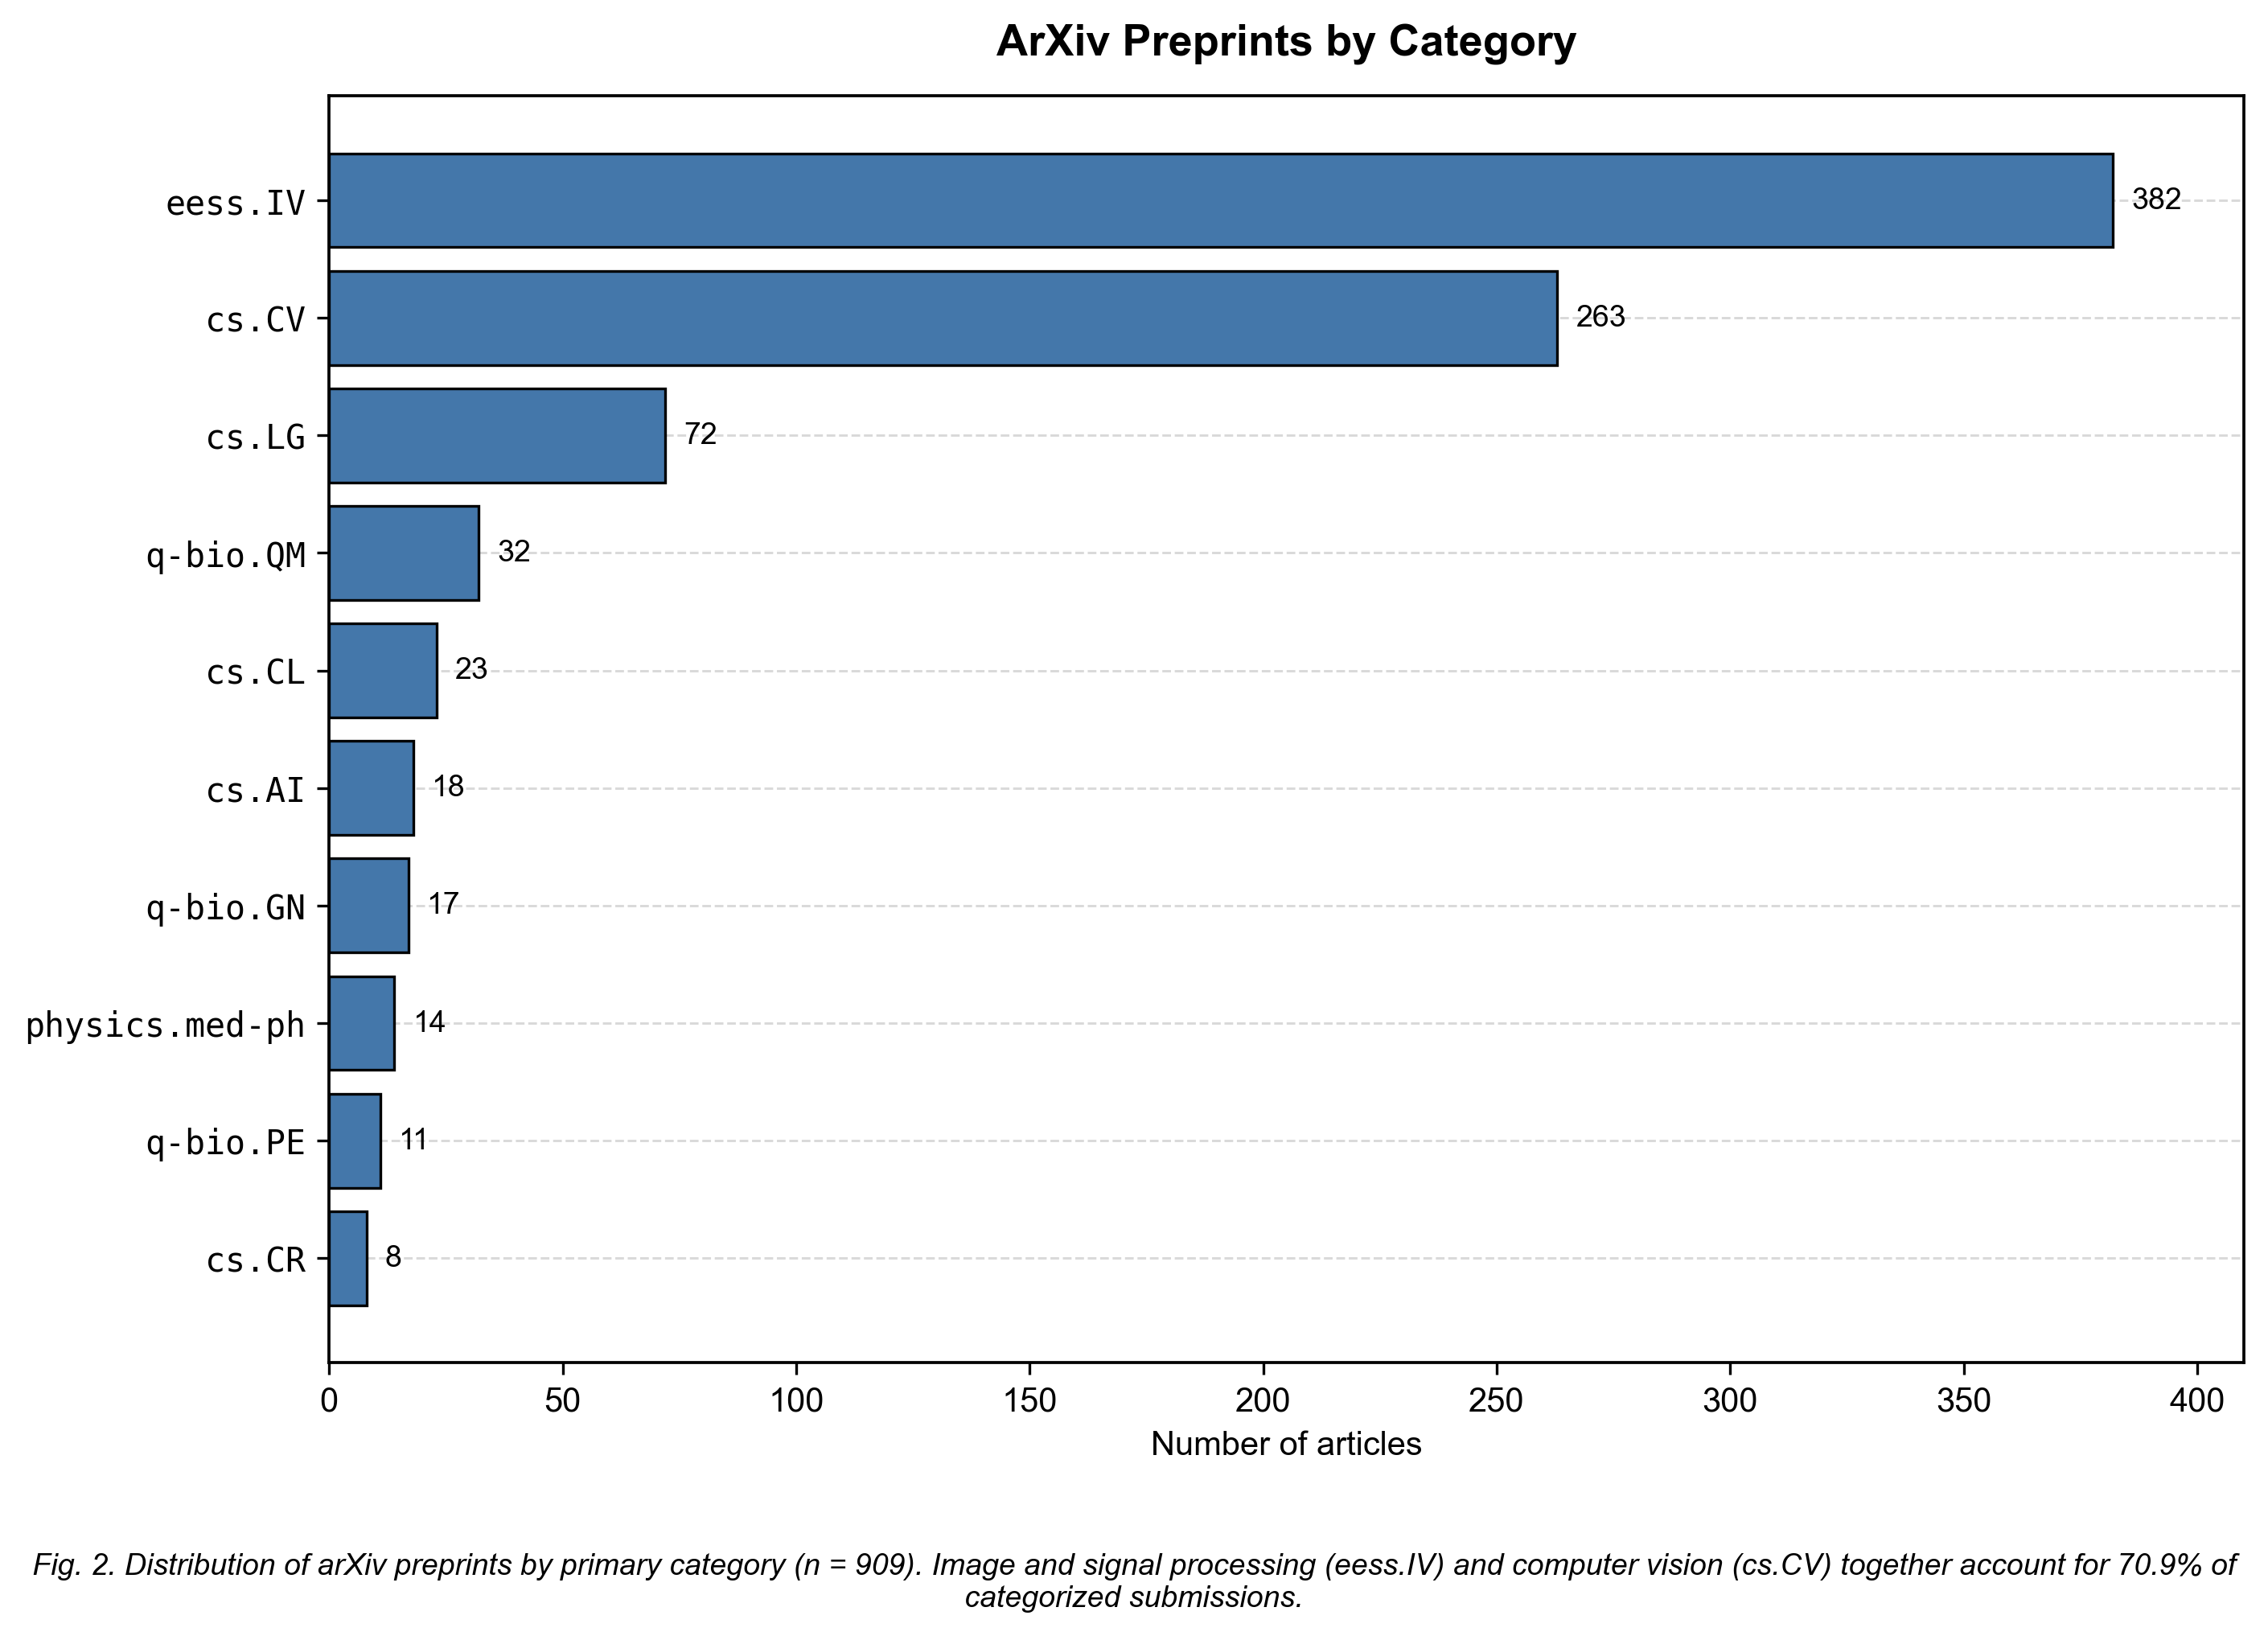

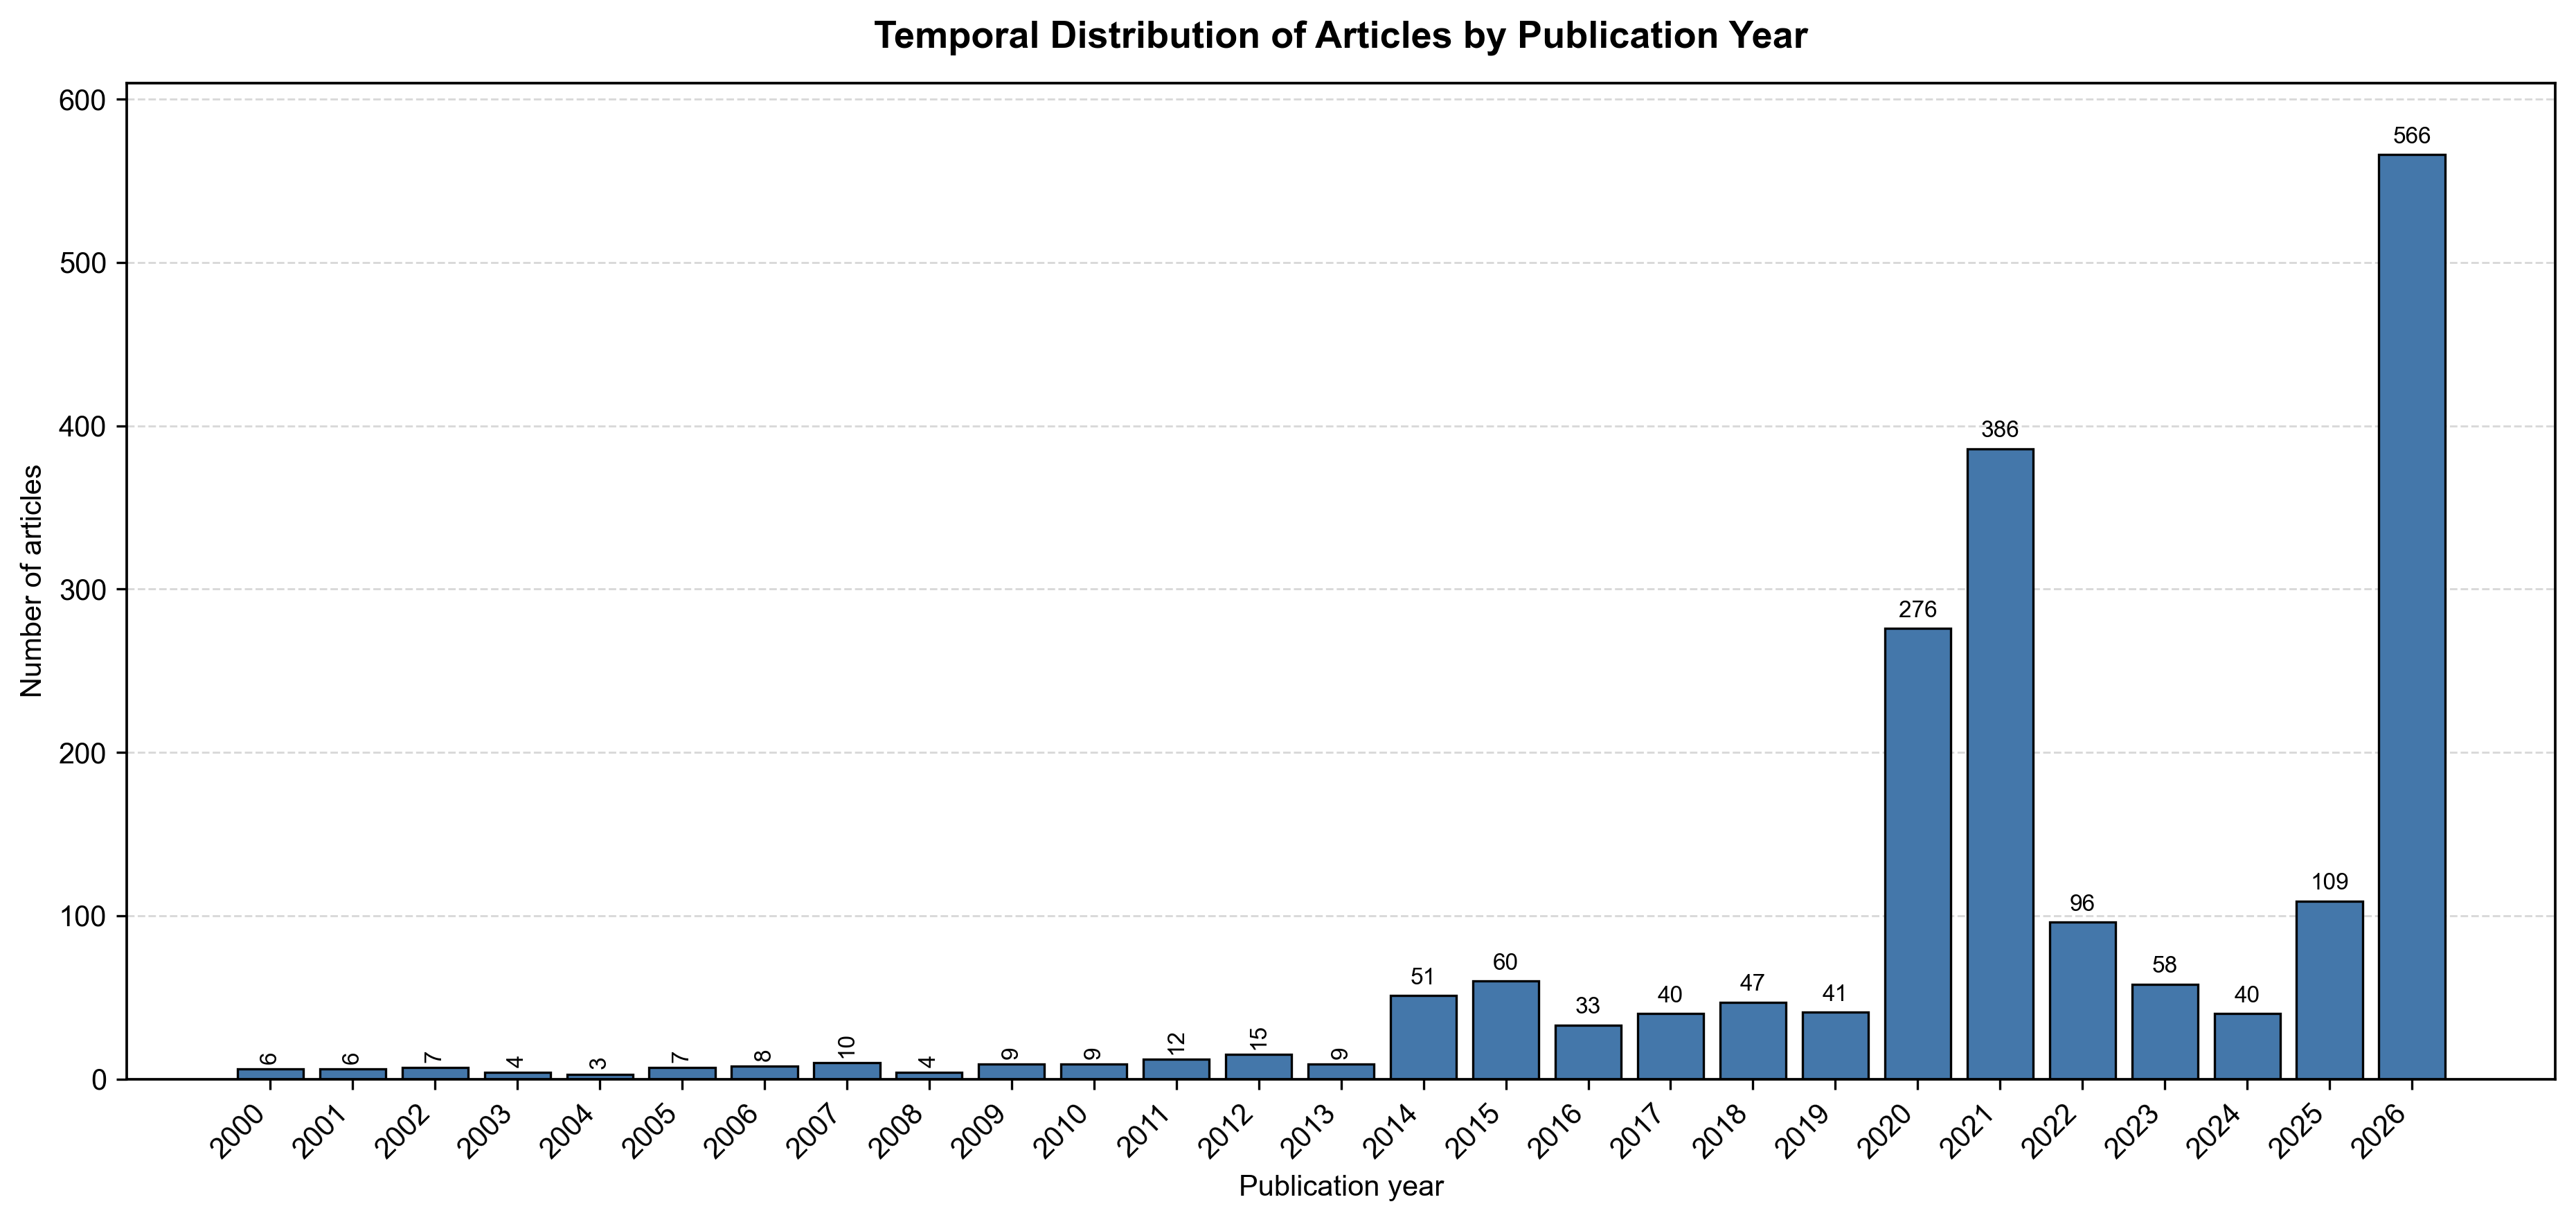

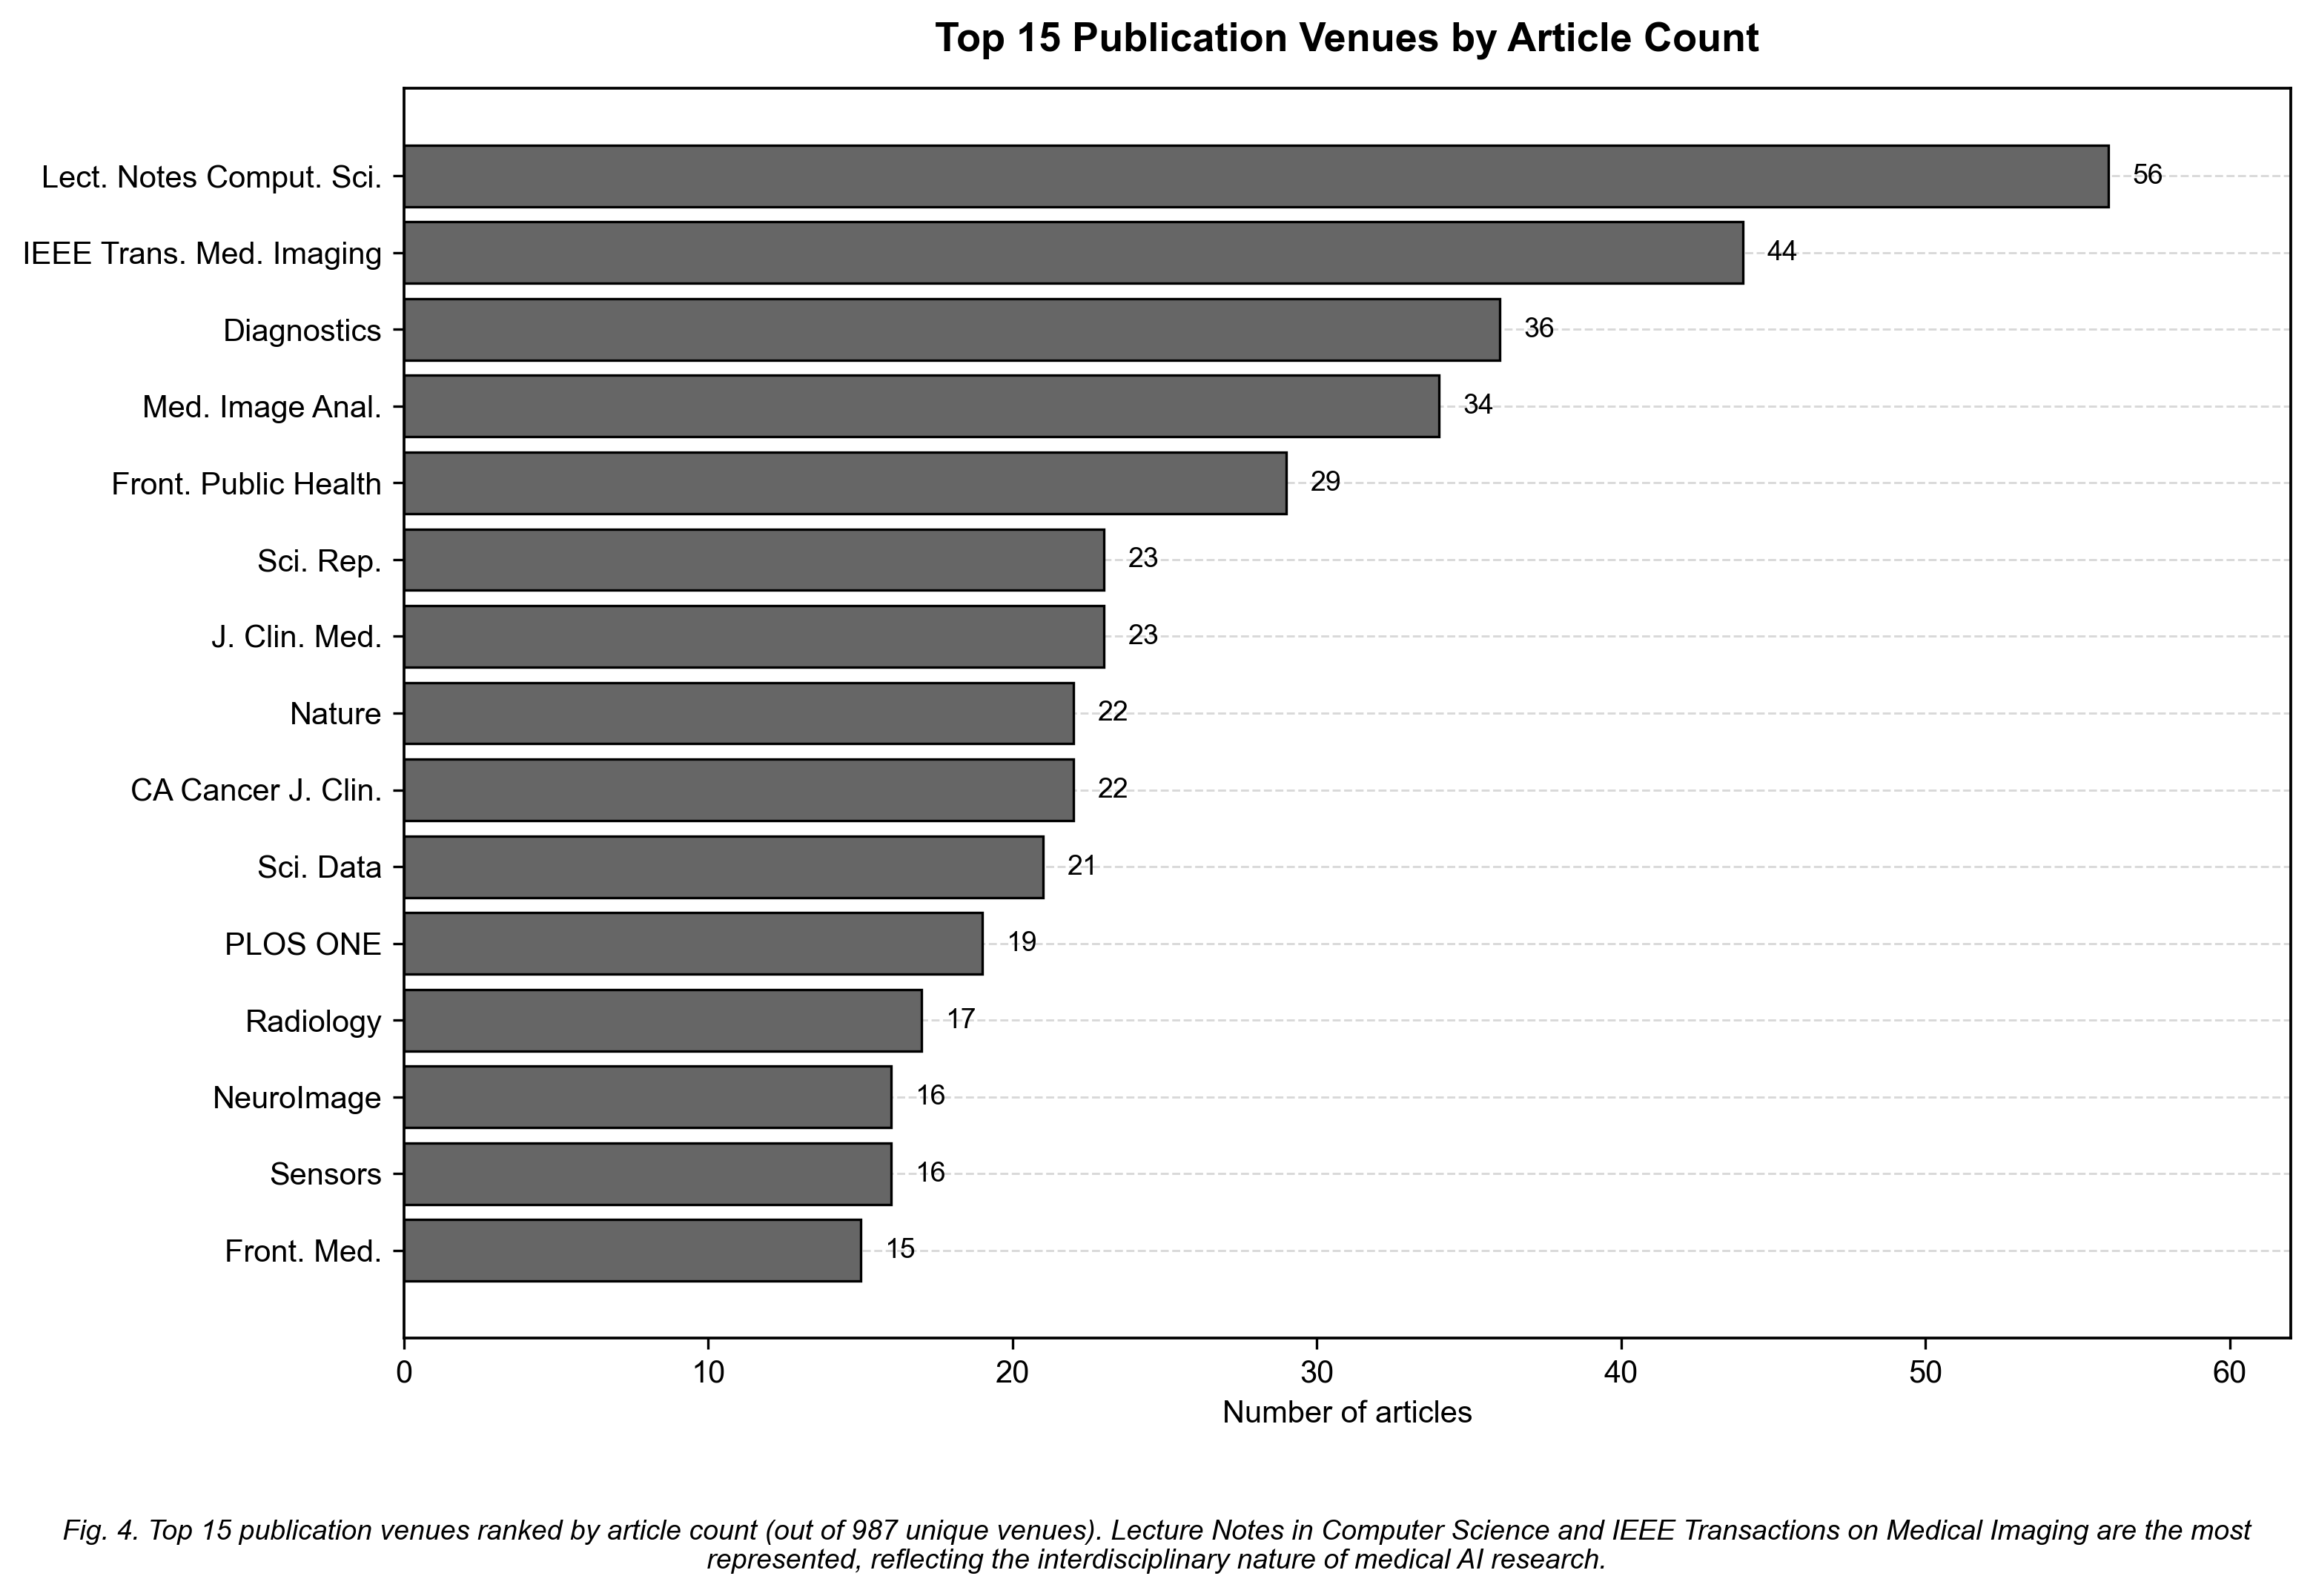

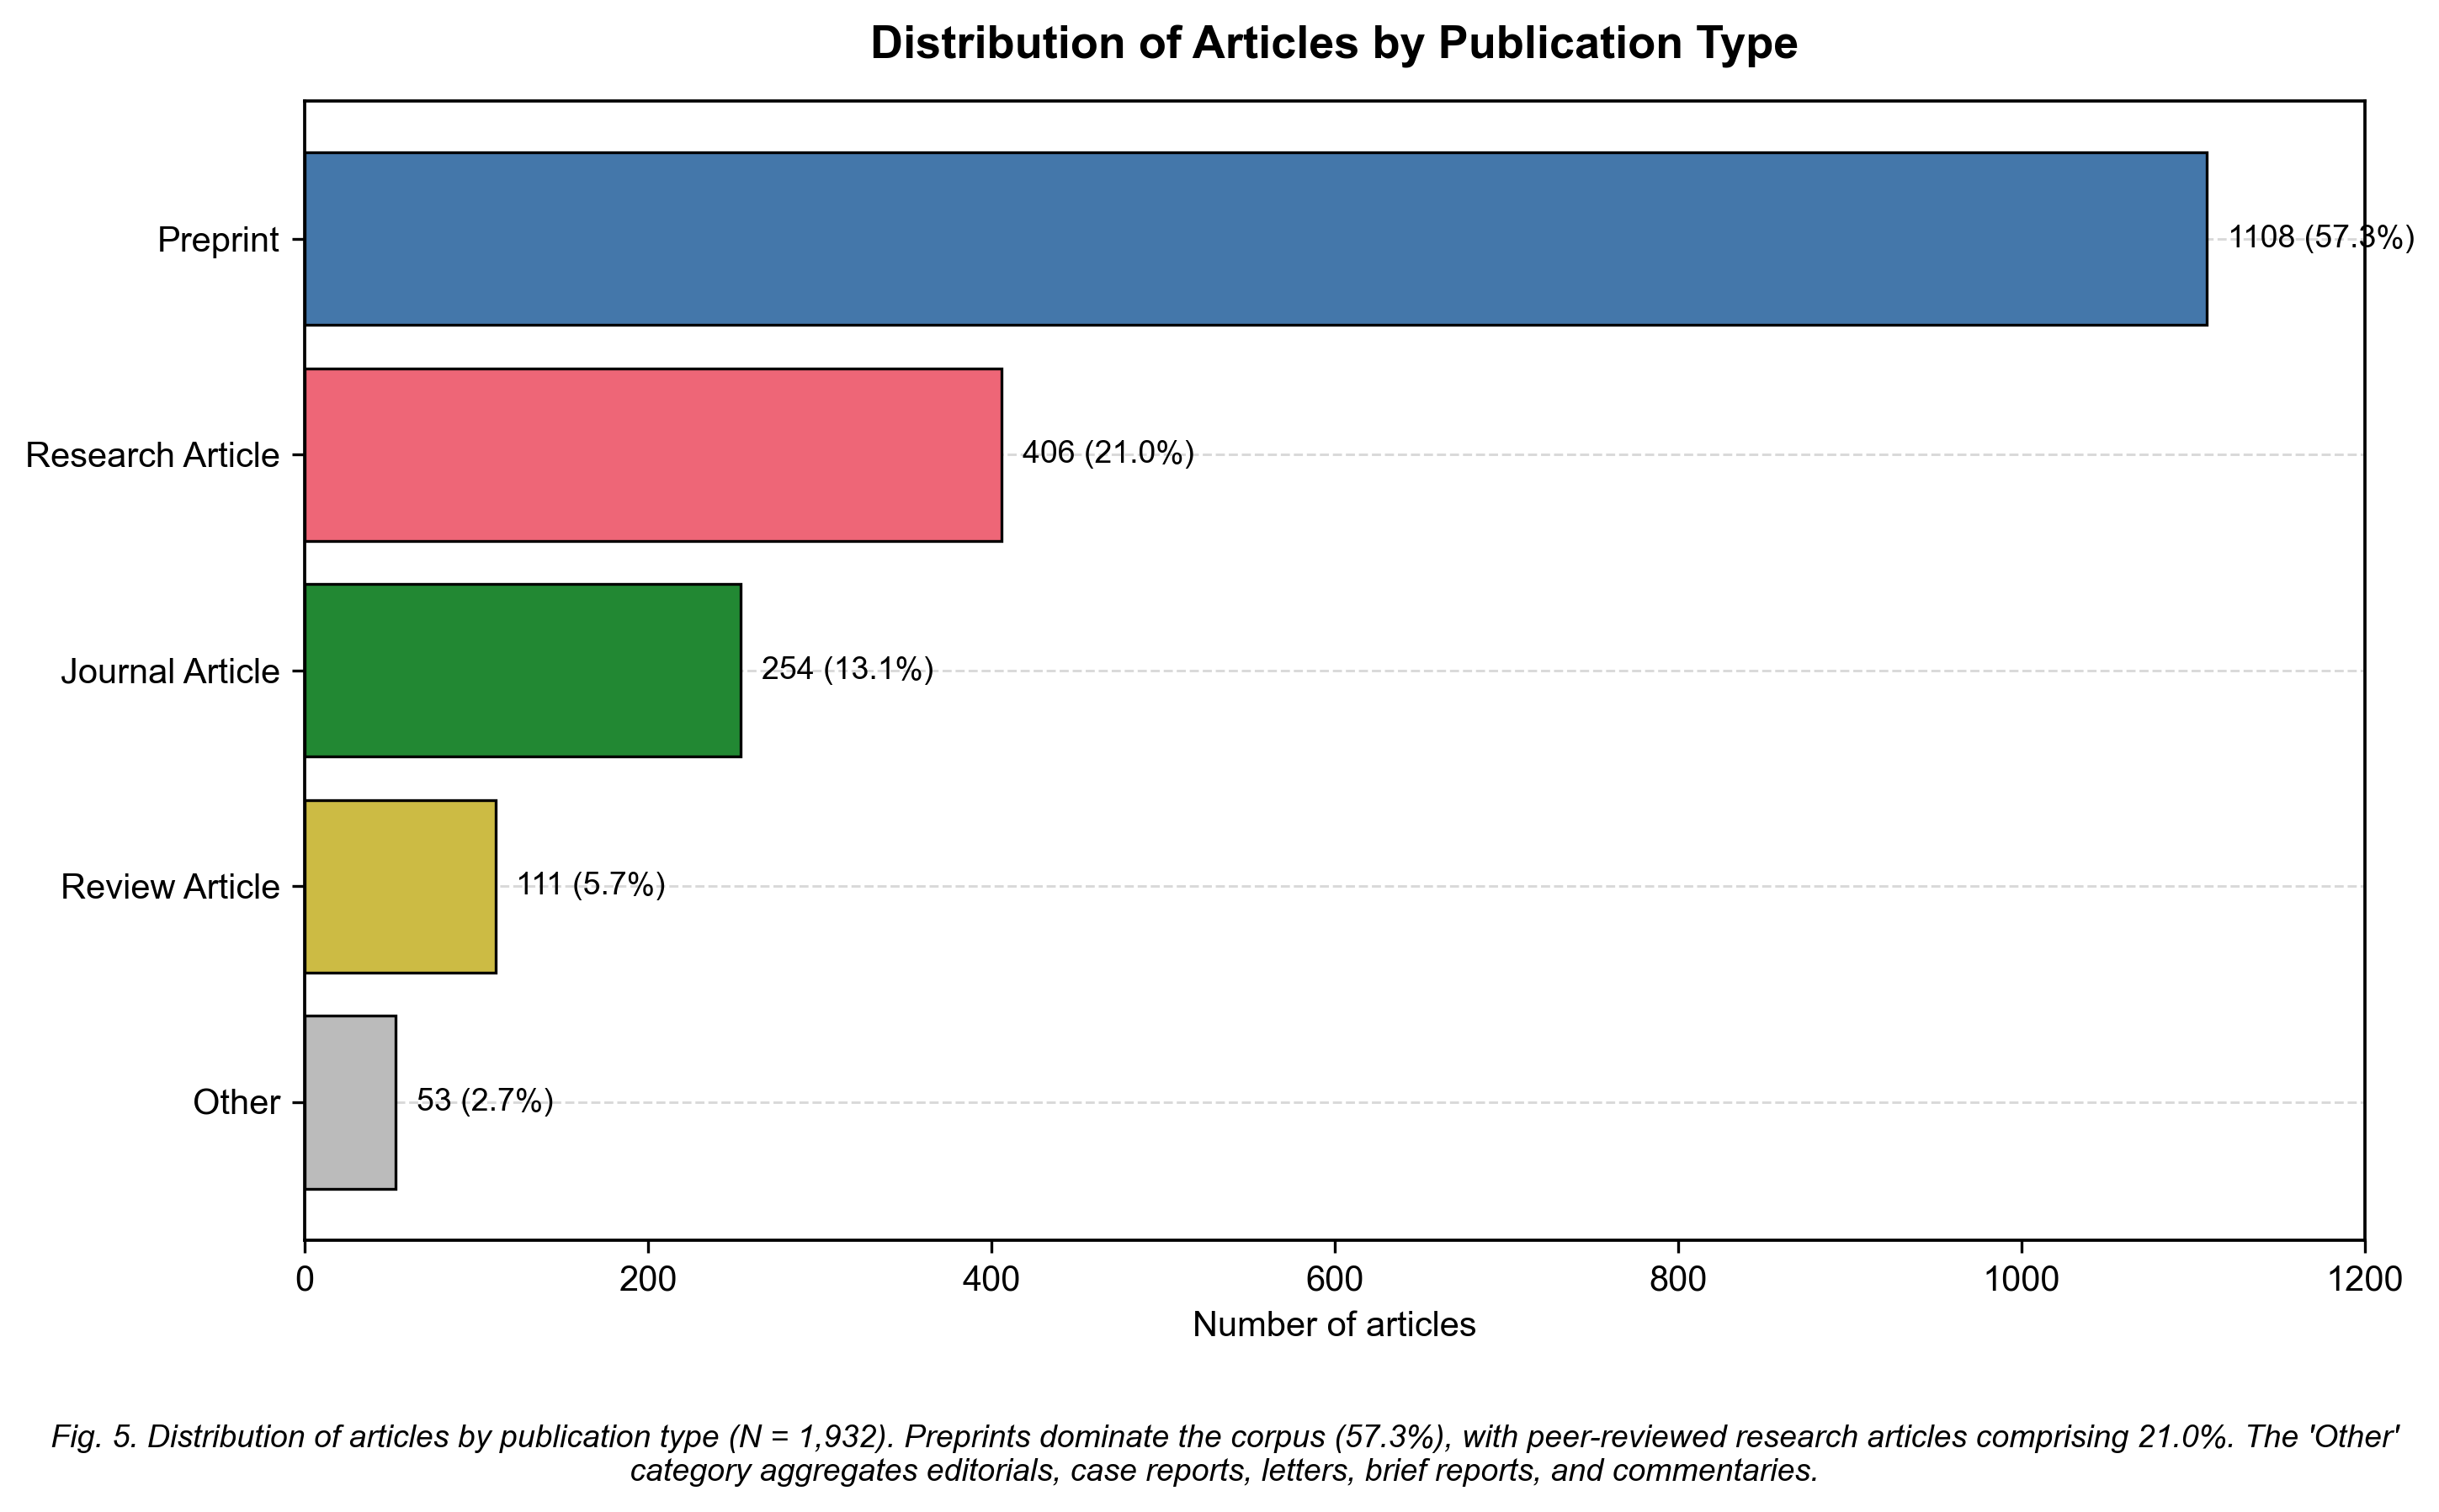

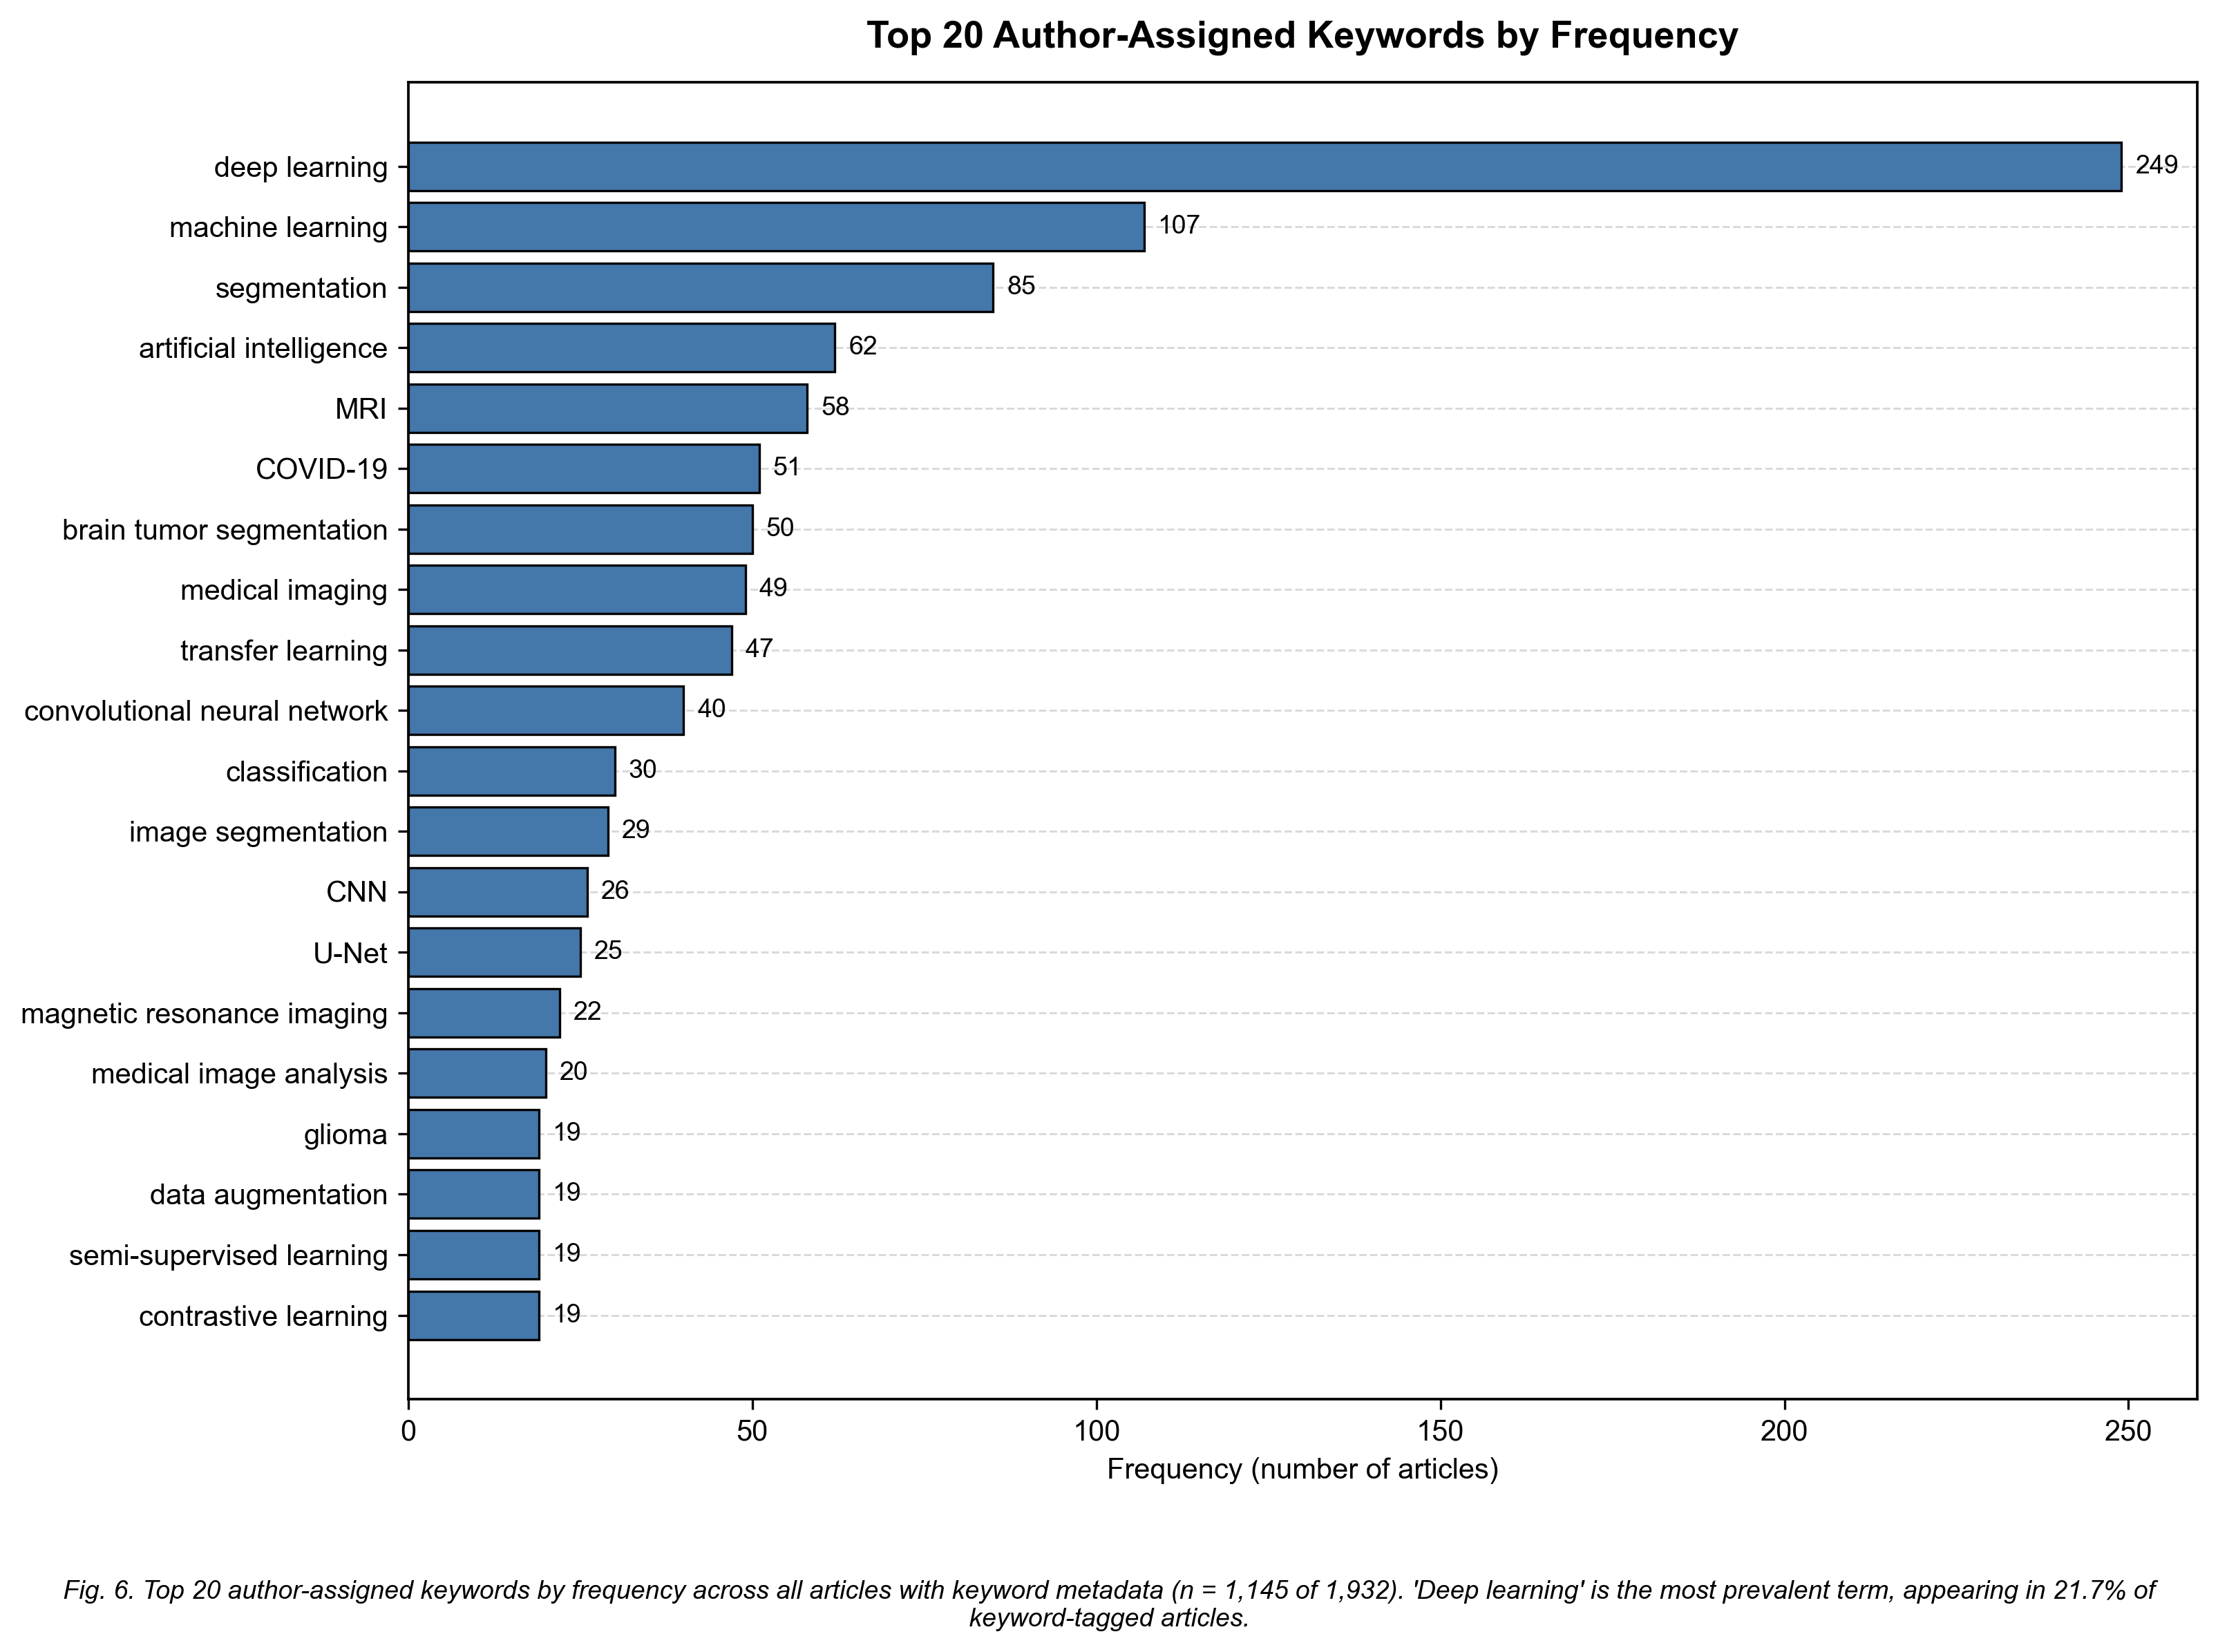

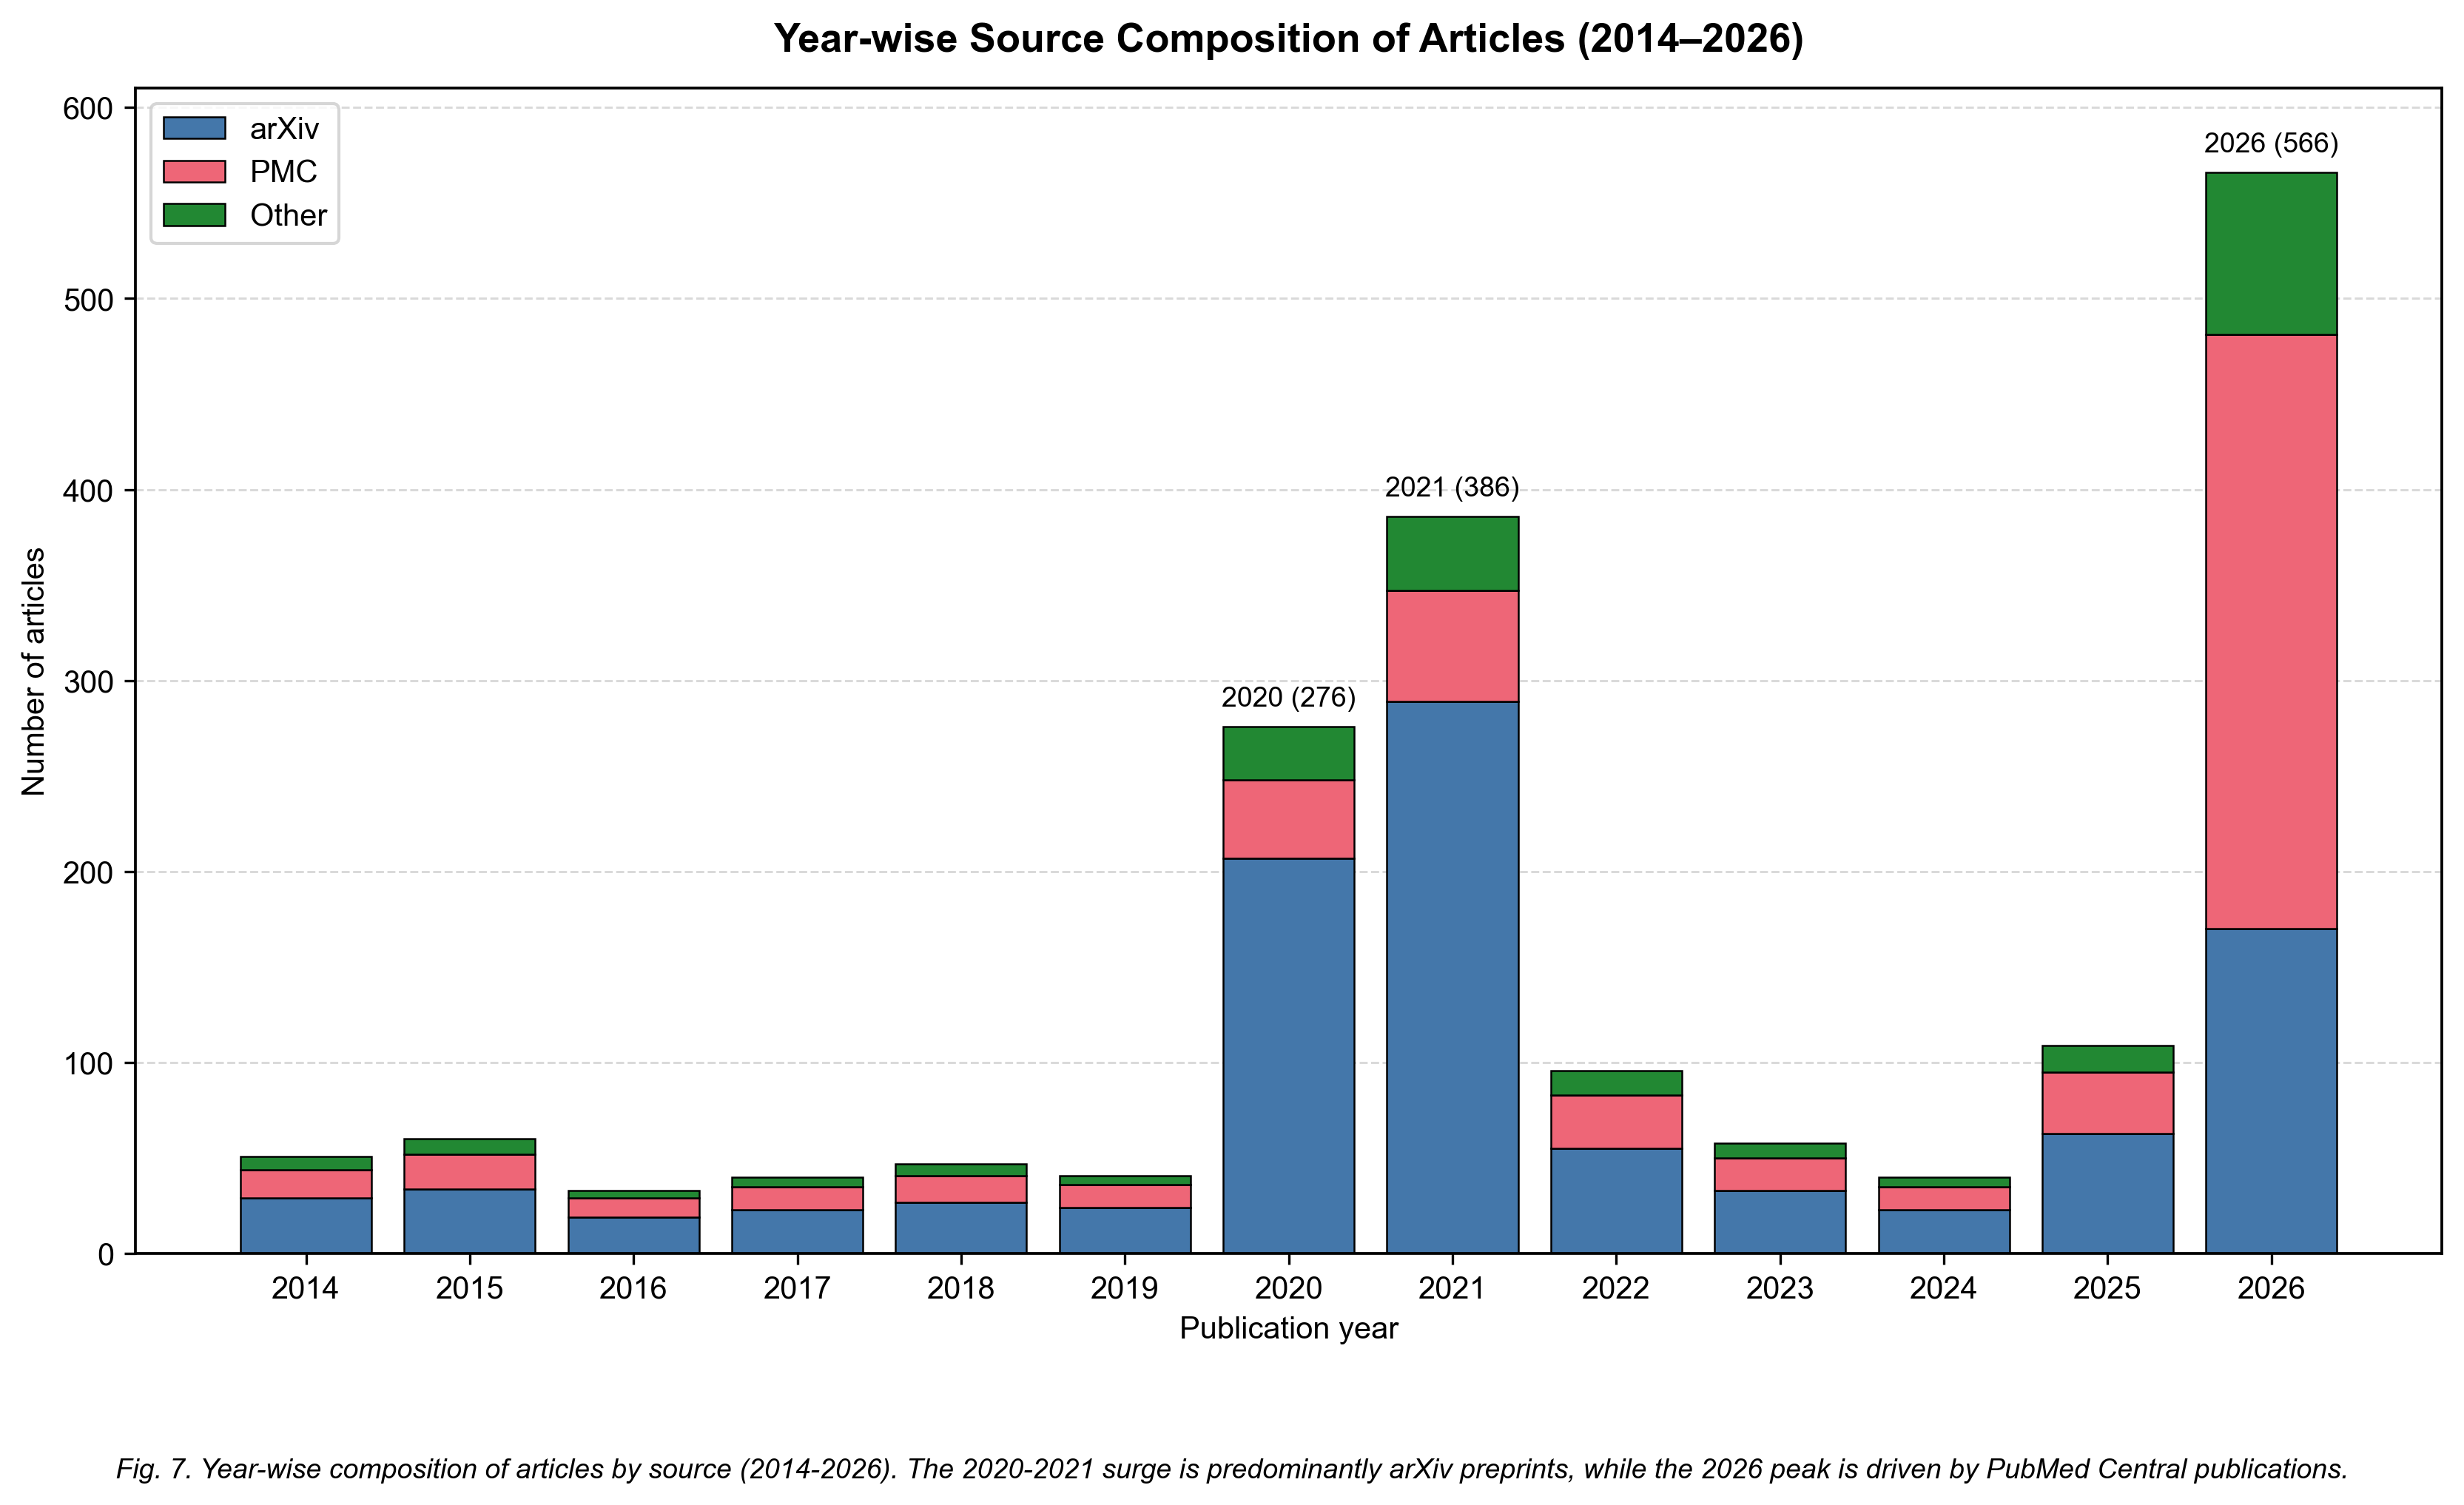

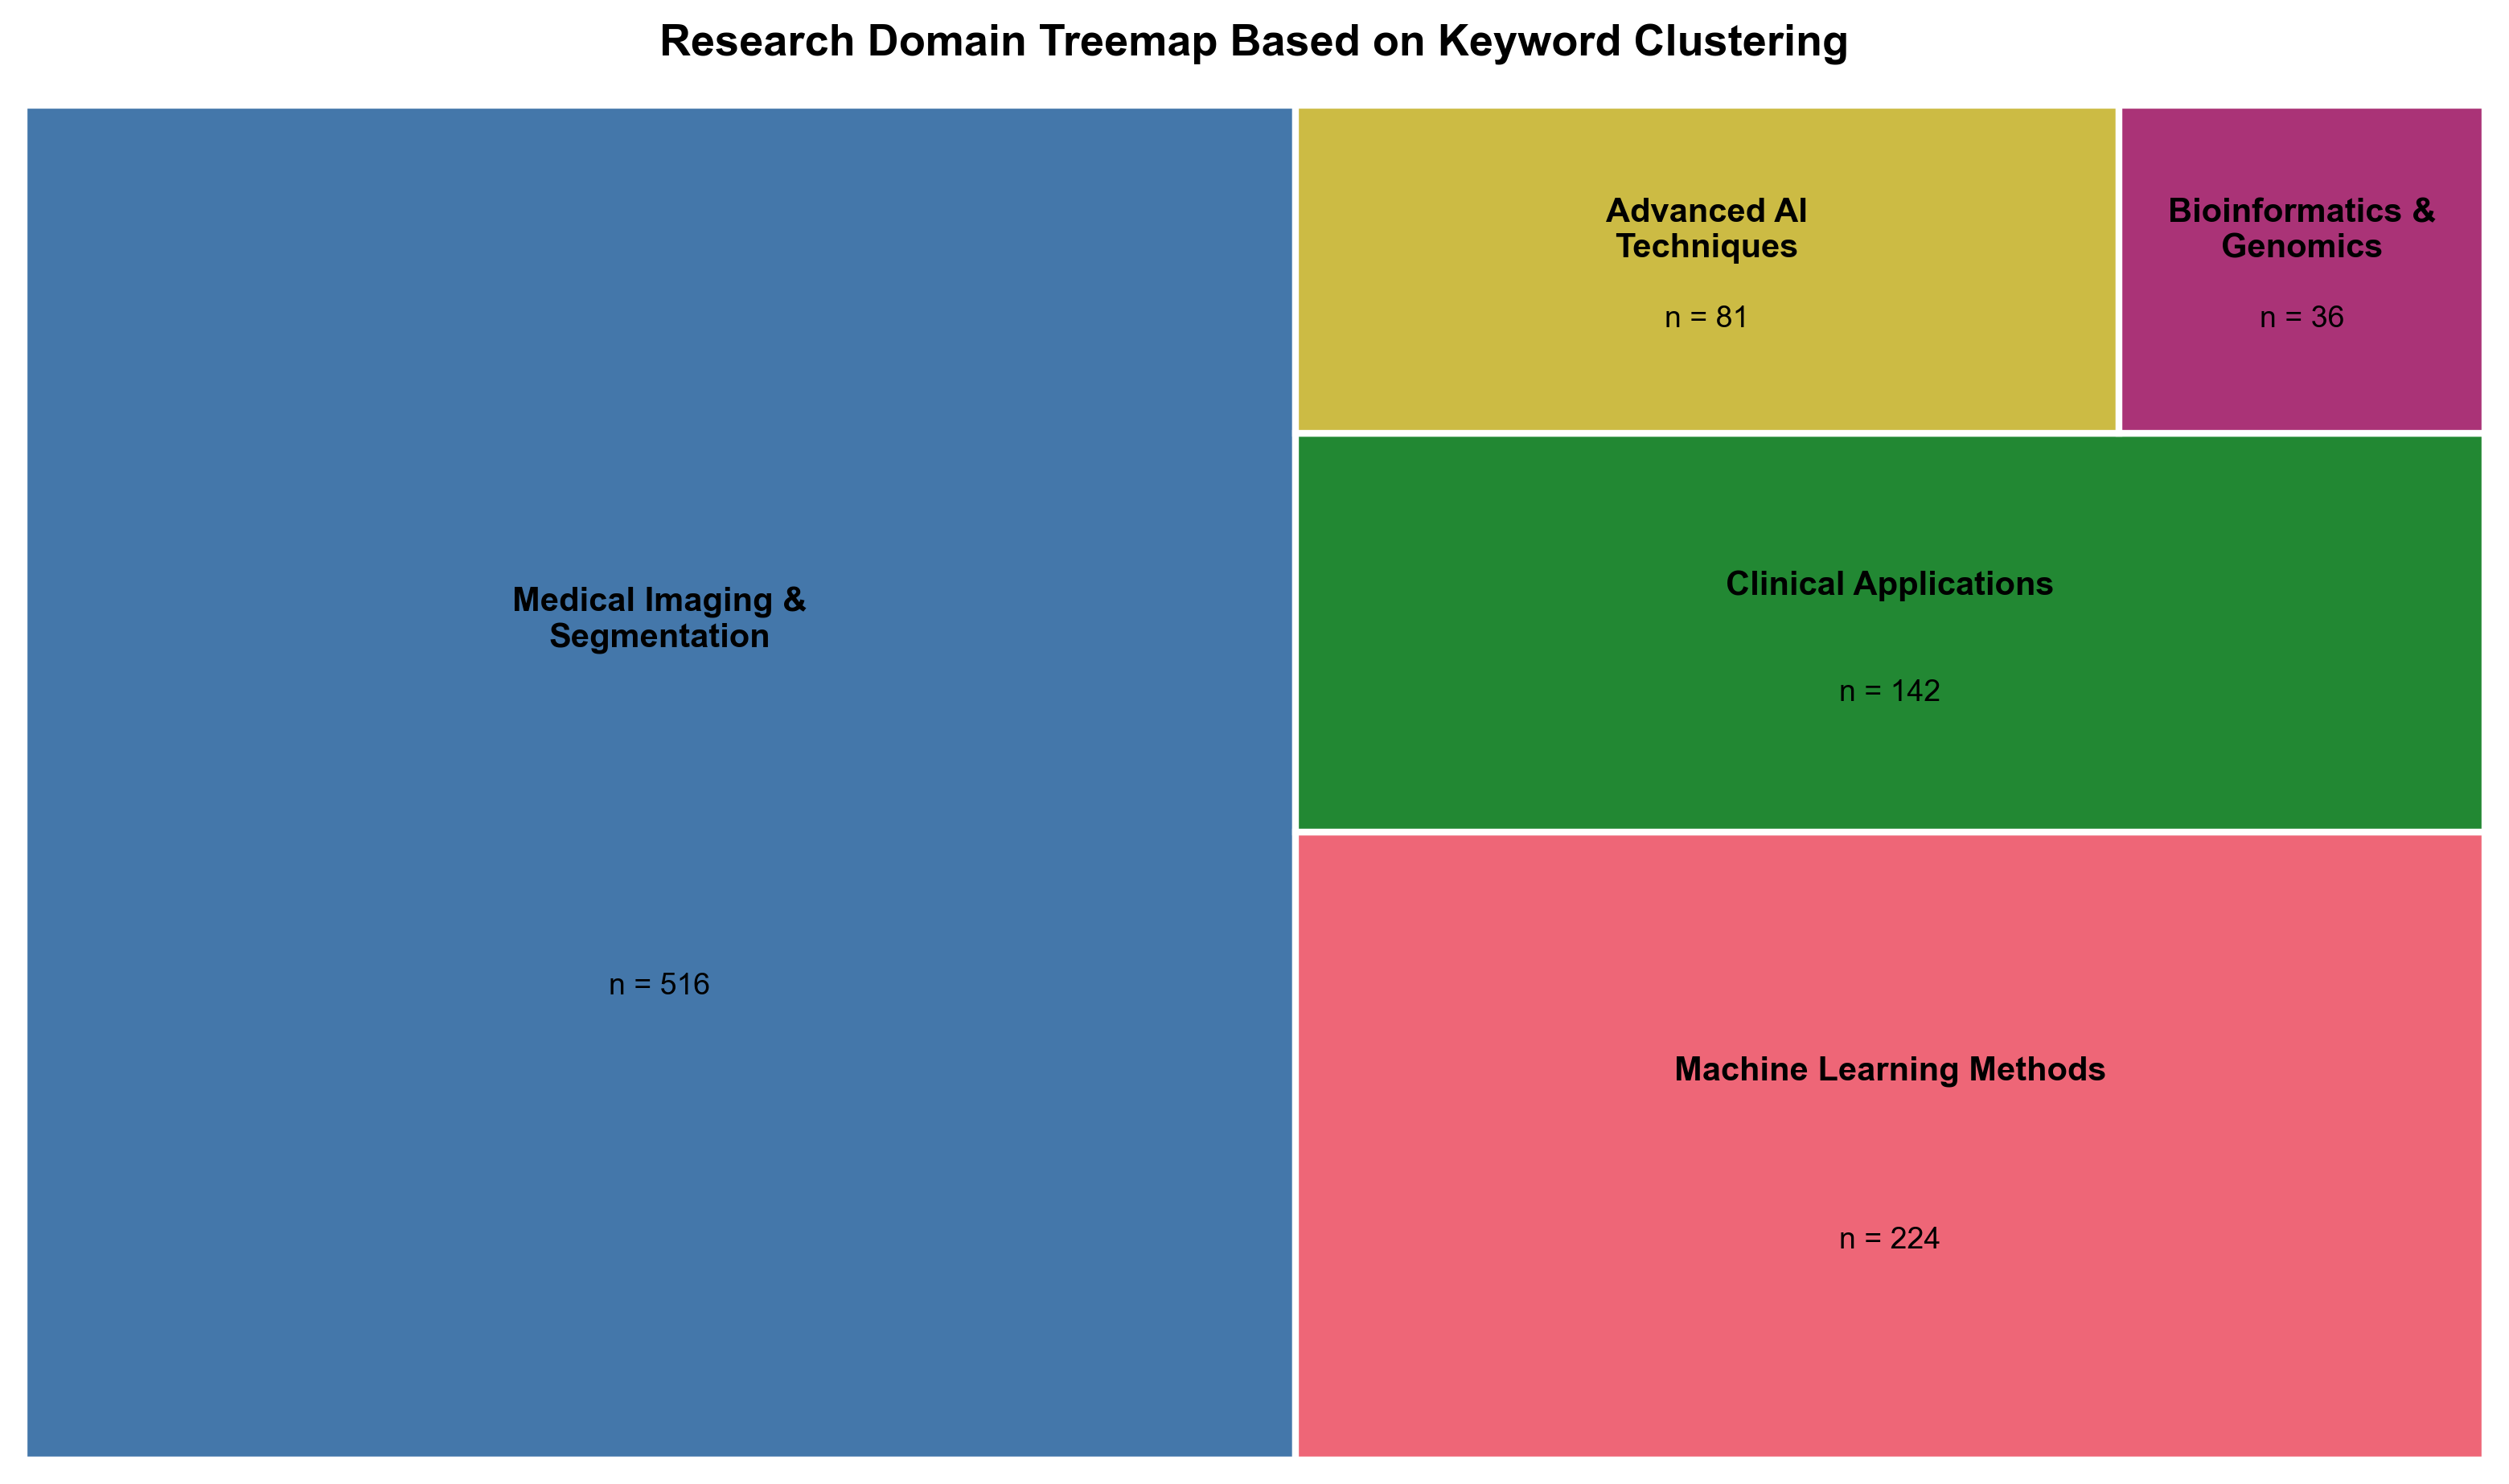

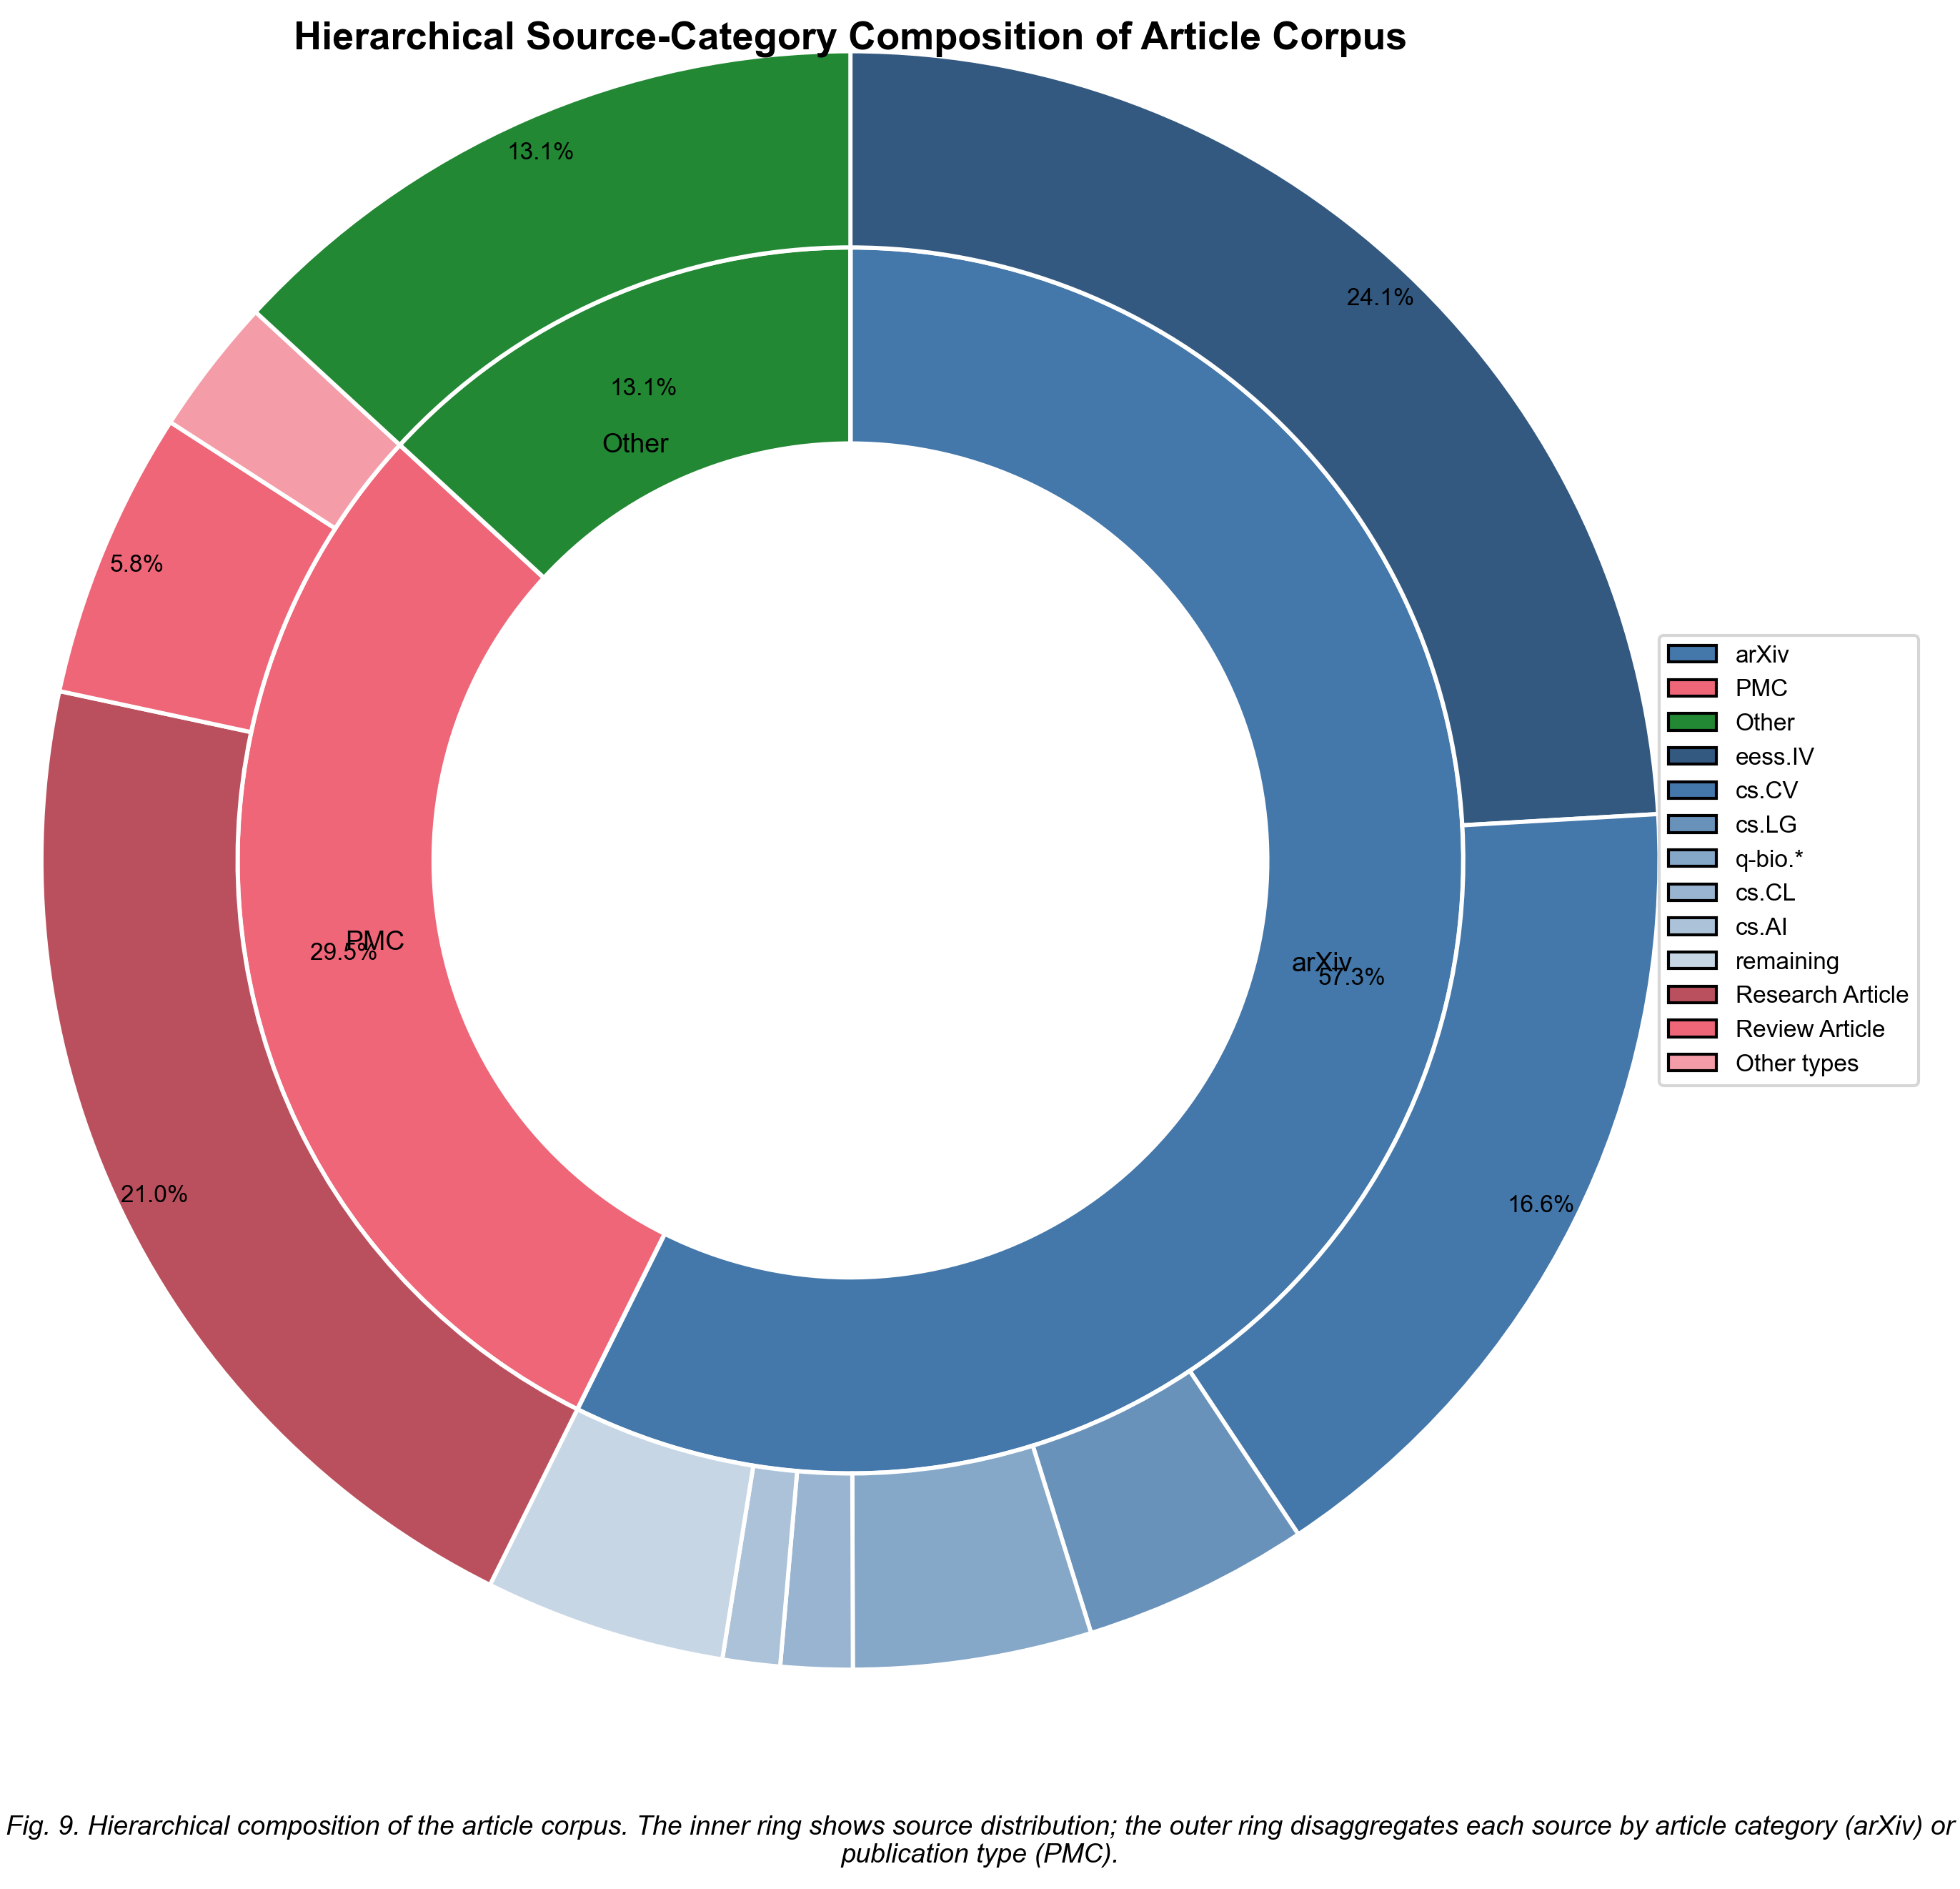

Done. Figures saved to: C:\Users\DELL\Desktop\NSU\Thesis\Gliner\MedNER\visualization\plots


In [5]:
def plot_figure5_article_type_distribution(fancy=False):
    apply_style(fancy)
    labels = list(ARTICLE_TYPES.keys())
    values = list(ARTICLE_TYPES.values())
    total = sum(values)

    colors = [PALETTE["blue"], PALETTE["red"], PALETTE["teal"], PALETTE["amber"], PALETTE["gray"]]

    y = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(9.8, 6.0), dpi=300)
    ax.barh(y, values, color=colors, edgecolor="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlim(0, 1200)
    ax.set_xticks(np.arange(0, 1201, 200))

    for yi, v in zip(y, values):
        pct = v * 100 / total
        ax.text(v + 12, yi, f"{v} ({pct:.1f}%)", va="center", ha="left", fontsize=9)

    style_axes(ax, xlabel="Number of articles", y_grid=True)
    ax.set_title("Distribution of Articles by Publication Type", fontsize=13, fontweight="bold", pad=12)

    caption = (
        "Fig. 5. Distribution of articles by publication type (N = 1,932). Preprints dominate "
        "the corpus (57.3%), with peer-reviewed research articles comprising 21.0%. The 'Other' "
        "category aggregates editorials, case reports, letters, brief reports, and commentaries."
    )
    add_caption(fig, caption)
    finalize_figure(fig, "fig5_article_type_distribution.png")


def plot_figure6_keyword_frequency(fancy=False):
    apply_style(fancy)
    labels = list(KEYWORD_TOP20.keys())
    values = list(KEYWORD_TOP20.values())

    y = np.arange(len(labels))
    fig, ax = plt.subplots(figsize=(10.8, 8.0), dpi=300)
    ax.barh(y, values, color=PALETTE["blue"], edgecolor="black", linewidth=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()
    ax.set_xlim(0, 260)
    ax.set_xticks(np.arange(0, 251, 50))

    for yi, v in zip(y, values):
        ax.text(v + 2, yi, str(v), va="center", ha="left", fontsize=9)

    style_axes(ax, xlabel="Frequency (number of articles)", y_grid=True)
    ax.set_title("Top 20 Author-Assigned Keywords by Frequency", fontsize=13, fontweight="bold", pad=12)

    caption = (
        "Fig. 6. Top 20 author-assigned keywords by frequency across all articles with keyword "
        "metadata (n = 1,145 of 1,932). 'Deep learning' is the most prevalent term, appearing "
        "in 21.7% of keyword-tagged articles."
    )
    add_caption(fig, caption)
    finalize_figure(fig, "fig6_research_keyword_frequency.png")


def plot_figure7_yearwise_source_composition(fancy=False):
    apply_style(fancy)
    years, data = get_year_source_data_2014_2026()

    arxiv = np.array([data[y]["arXiv"] for y in years])
    pmc = np.array([data[y]["PMC"] for y in years])
    other = np.array([data[y]["Other"] for y in years])
    totals = arxiv + pmc + other

    fig, ax = plt.subplots(figsize=(11.2, 6.8), dpi=300)
    ax.bar(years, arxiv, color=PALETTE["blue"], edgecolor="black", linewidth=0.6, label="arXiv")
    ax.bar(years, pmc, bottom=arxiv, color=PALETTE["red"], edgecolor="black", linewidth=0.6, label="PMC")
    ax.bar(years, other, bottom=arxiv + pmc, color=PALETTE["teal"], edgecolor="black", linewidth=0.6, label="Other")

    for year in [2020, 2021, 2026]:
        idx = years.index(year)
        ax.text(year, totals[idx] + 8, f"{year} ({int(totals[idx])})", ha="center", va="bottom", fontsize=9)

    ax.set_ylim(0, 610)
    ax.set_yticks(np.arange(0, 601, 100))
    ax.set_xticks(years)

    style_axes(ax, xlabel="Publication year", ylabel="Number of articles", y_grid=True)
    ax.set_title("Year-wise Source Composition of Articles (2014–2026)", fontsize=13, fontweight="bold", pad=12)
    ax.legend(loc="upper left", frameon=True)

    caption = (
        "Fig. 7. Year-wise composition of articles by source (2014-2026). The 2020-2021 surge "
        "is predominantly arXiv preprints, while the 2026 peak is driven by PubMed Central "
        "publications."
    )
    add_caption(fig, caption)
    finalize_figure(fig, "fig7_yearwise_source_composition.png")


def _binary_treemap_layout(items, x=0.0, y=0.0, w=1.0, h=1.0):
    if len(items) == 1:
        return [(x, y, w, h, items[0])]

    total = sum(v for _, v, _ in items)
    best_idx = 1
    best_diff = float("inf")
    acc = 0

    for i in range(1, len(items)):
        acc += items[i - 1][1]
        diff = abs(total / 2 - acc)
        if diff < best_diff:
            best_diff = diff
            best_idx = i

    left = items[:best_idx]
    right = items[best_idx:]
    left_sum = sum(v for _, v, _ in left)

    if w >= h:
        w_left = w * (left_sum / total)
        return _binary_treemap_layout(left, x, y, w_left, h) + _binary_treemap_layout(right, x + w_left, y, w - w_left, h)

    h_top = h * (left_sum / total)
    return _binary_treemap_layout(left, x, y, w, h_top) + _binary_treemap_layout(right, x, y + h_top, w, h - h_top)


def plot_figure8_domain_treemap(fancy=False):
    import textwrap
    apply_style(fancy)
    items = sorted(TREEMAP_DOMAINS, key=lambda t: t[1], reverse=True)
    boxes = _binary_treemap_layout(items)

    fig, ax = plt.subplots(figsize=(10.5, 6.8), dpi=300)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    for x, y, w, h, (label, val, color) in boxes:
        rect = Rectangle((x, y), w, h, facecolor=color, edgecolor="white", linewidth=2.0)
        ax.add_patch(rect)
        cx, cy = x + w / 2, y + h / 2

        # Wrap text at word boundaries, minimize wrapping for small boxes
        max_chars = max(18, int(w * 55))
        wrapped_label = textwrap.fill(label, width=max_chars)

        ax.text(cx, cy + 0.12 * h, wrapped_label, ha="center", va="center", fontsize=10, fontweight="bold", color="black", wrap=True)
        ax.text(cx, cy - 0.15 * h, f"n = {val}", ha="center", va="center", fontsize=9, color="black")

    ax.set_title("Research Domain Treemap Based on Keyword Clustering", fontsize=13, fontweight="bold", pad=15)
    ax.axis("off")

    finalize_figure(fig, "fig8_research_domain_treemap.png")


def _annotate_wedge_percents(ax, wedges, values, total, threshold=0.05, radius=1.0):
    for w, v in zip(wedges, values):
        pct = v / total
        if pct < threshold:
            continue
        angle = np.deg2rad((w.theta1 + w.theta2) / 2)
        x = np.cos(angle) * radius
        y = np.sin(angle) * radius
        ax.text(x, y, f"{pct*100:.1f}%", ha="center", va="center", fontsize=8)


def plot_figure9_hierarchical_sunburst(fancy=False):
    apply_style(fancy)

    inner_labels = ["arXiv", "PMC", "Other"]
    inner_values = [1108, 570, 254]
    total_n = sum(inner_values)
    inner_colors = [PALETTE["blue"], PALETTE["red"], PALETTE["teal"]]

    arxiv_splits = [
        ("eess.IV", 42.0),
        ("cs.CV", 28.9),
        ("cs.LG", 7.9),
        ("q-bio.*", 8.3),
        ("cs.CL", 2.5),
        ("cs.AI", 2.0),
        ("remaining", 8.4),
    ]
    pmc_splits = [("Research Article", 71.2), ("Review Article", 19.5), ("Other types", 9.3)]

    outer_labels = []
    outer_values = []
    outer_colors = []

    arxiv_shades = [
        blend_with_black(PALETTE["blue"], 0.25),
        PALETTE["blue"],
        blend_with_white(PALETTE["blue"], 0.20),
        blend_with_white(PALETTE["blue"], 0.35),
        blend_with_white(PALETTE["blue"], 0.45),
        blend_with_white(PALETTE["blue"], 0.55),
        blend_with_white(PALETTE["blue"], 0.70),
    ]

    pmc_shades = [
        blend_with_black(PALETTE["red"], 0.22),
        PALETTE["red"],
        blend_with_white(PALETTE["red"], 0.35),
    ]

    for (lbl, pct), color in zip(arxiv_splits, arxiv_shades):
        outer_labels.append(lbl)
        outer_values.append(inner_values[0] * pct / 100.0)
        outer_colors.append(color)

    for (lbl, pct), color in zip(pmc_splits, pmc_shades):
        outer_labels.append(lbl)
        outer_values.append(inner_values[1] * pct / 100.0)
        outer_colors.append(color)

    outer_labels.append("Other")
    outer_values.append(inner_values[2])
    outer_colors.append(PALETTE["teal"])

    fig, ax = plt.subplots(figsize=(9.0, 9.0), dpi=300)

    inner_wedges, _ = ax.pie(
        inner_values,
        radius=1.0,
        labels=inner_labels,
        labeldistance=0.74,
        colors=inner_colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.32, edgecolor="white", linewidth=1.5),
        textprops=dict(fontsize=9),
    )

    outer_wedges, _ = ax.pie(
        outer_values,
        radius=1.32,
        labels=None,
        colors=outer_colors,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.32, edgecolor="white", linewidth=1.4),
    )

    _annotate_wedge_percents(ax, inner_wedges, inner_values, total_n, threshold=0.05, radius=0.84)
    _annotate_wedge_percents(ax, outer_wedges, outer_values, total_n, threshold=0.05, radius=1.26)

    legend_labels = [
        "arXiv", "PMC", "Other",
        "eess.IV", "cs.CV", "cs.LG", "q-bio.*", "cs.CL", "cs.AI", "remaining",
        "Research Article", "Review Article", "Other types",
    ]
    legend_colors = [
        PALETTE["blue"], PALETTE["red"], PALETTE["teal"],
        *arxiv_shades,
        *pmc_shades,
    ]
    handles = [Patch(facecolor=c, edgecolor="black", label=l) for l, c in zip(legend_labels, legend_colors)]
    ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=True)

    ax.set_title("Hierarchical Source-Category Composition of Article Corpus", fontsize=13, fontweight="bold", pad=15)
    ax.set_aspect("equal")

    caption = (
        "Fig. 9. Hierarchical composition of the article corpus. The inner ring shows source "
        "distribution; the outer ring disaggregates each source by article category (arXiv) "
        "or publication type (PMC)."
    )
    add_caption(fig, caption)
    finalize_figure(fig, "fig9_hierarchical_source_category_sunburst.png")


def generate_all_figures(fancy_style=False):
    print(f"Generating figures with fancy_style={fancy_style} ...")
    plot_figure1_source_distribution(fancy=fancy_style)
    plot_figure2_arxiv_breakdown(fancy=fancy_style)
    plot_figure3_year_distribution(fancy=fancy_style)
    plot_figure4_top_venues(fancy=fancy_style)
    plot_figure5_article_type_distribution(fancy=fancy_style)
    plot_figure6_keyword_frequency(fancy=fancy_style)
    plot_figure7_yearwise_source_composition(fancy=fancy_style)
    plot_figure8_domain_treemap(fancy=fancy_style)
    plot_figure9_hierarchical_sunburst(fancy=fancy_style)
    print(f"Done. Figures saved to: {OUTPUT_DIR.resolve()}")


generate_all_figures(fancy_style=FANCY_STYLE)
